In [2]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Excel file into a DataFrame
df = pd.read_excel('FULL ESG DATA 25.03.xlsx', header=[0, 1],
                          skiprows=[2,2],
                            #nrows=10
                            )

# Print the DataFrame
df


Identifier                  Company Name  \
     Unnamed: 0_level_1            Unnamed: 1_level_1   
0                110448  British American Tobacco plc   
1                204386                        CGG SA   
2                225313            Credit Agricole SA   
3                251525              Deutsche Bank AG   
4                251566           Deutsche Telekom AG   
...                 ...                           ...   
1094             94846C                Rizzo Group AB   
1095             65527N              Nokian Tyres plc   
1096             86466Q                 Suedzucker AG   
1097             31529L                  Ferretti SpA   
1098             95074Q                 Wereldhave NV   

     ESG Score Grade\nIn the last 7 FY                                \
                                   FY0 FY-1 FY-2 FY-3 FY-4 FY-5 FY-6   
0                                    A   A+   A+    A    A   A-   A-   
1                                   A-   B+   B+   B+   B+   B+    B   
2                                    B   B+   B+    B   B+    B    B   
3                                    A   A-    A    A   A-   A-   A-   
4                                   A-    A    A   A-   A-   A-   A-   
...                                ...  ...  ...  ...  ...  ...  ...   
1094                               NaN  NaN  NaN  NaN  NaN  NaN  NaN   
1095                                 B    B    B    B    B    B   C+   
1096                                 B    B    B   B-   C+   C+   C+   
1097                               NaN  NaN  NaN  NaN  NaN  NaN  NaN   
1098                                B-   B-    B   B-    B    B   B-   

     ESG Combined Score Grade\nIn the last 7 FY  ...  \
                                            FY0  ...   
0                                            C+  ...   
1                                            A-  ...   
2                                            C+  ...   
3                                            C+  ...   
4                                            A-  ...   
...                                         ...  ...   
1094                                        NaN  ...   
1095                                          B  ...   
1096                                          B  ...   
1097                                        NaN  ...   
1098                                         B-  ...   

     ESG Combined Score\nIn the last 7 FY                        \
                                     FY-4       FY-5       FY-6   
0                               88.927167  61.328028  83.040627   
1                               69.567919  68.630067  66.396276   
2                               71.567016  41.135701  44.962708   
3                               41.051302  41.198827  38.818330   
4                               66.479803  76.985986  48.985011   
...                                   ...        ...        ...   
1094                                  NaN        NaN        NaN   
1095                            52.508811  58.782984  47.952315   
1096                            48.211760  44.367919  48.238682   
1097                                  NaN        NaN        NaN   
1098                            64.984199  61.522375  56.925180   

     ESG Controversies Score\nIn the last 7 FY                          \
                                           FY0        FY-1        FY-2   
0                                     4.729730   27.272727   14.473684   
1                                   100.000000  100.000000  100.000000   
2                                    26.699029   91.477273   45.000000   
3                                     2.743902    5.339806    1.704545   
4                                    79.166667   19.512195  100.000000   
...                                        ...         ...         ...   
1094                                       NaN         NaN         NaN   
1095                                 59.166667  100.000000   79.729

In [3]:
dfs = []
for col_name in df.columns.levels[0]:
    current_df = df.loc[:, (col_name, slice(None))]
    if current_df.dtypes[0] != 'object': # check if the column has numeric data
        current_df['average_score'] = None
        current_df['weight'] = None
        total_years = 0
        for index, row in current_df.iterrows():
            count = row.count()
            if count > 0:
                avg = row.sum() / count
                current_df.at[index, 'average_score'] = avg

            filtered_columns = [col for col in current_df.columns if 'FY' or 'D' in col[1]]
            available_years = row[filtered_columns].count()
            total_years += available_years

        for index, row in current_df.iterrows():
            filtered_columns = [col for col in current_df.columns if 'FY' or 'D' in col[1]]
            available_years = row[filtered_columns].count()
            current_df.at[index, 'weight'] = available_years / total_years

        current_df["avg_score_weighted"] = current_df["average_score"] * current_df["weight"]
        dfs.append(current_df)
import random

# randomly select 3 dataframes from the list
selected_dfs = random.sample(dfs, 3)

# print the selected dataframes
for df in selected_dfs:
    df
"""
for df in dfs:
    df.fillna(0, inplace=True)
"""

C:\Users\Coco\AppData\Local\Temp\ipykernel_8944\3219561171.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if current_df.dtypes[0] != 'object': # check if the column has numeric data
C:\Users\Coco\AppData\Local\Temp\ipykernel_8944\3219561171.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  current_df['average_score'] = None
C:\Users\Coco\AppData\Local\Temp\ipykernel_8944\3219561171.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in th

'\nfor df in dfs:\n    df.fillna(0, inplace=True)\n'

In [120]:
kmeans_df = pd.DataFrame()
for i,df in enumerate(dfs):
    weighted_avg_score = df.xs('avg_score_weighted', level=0, axis=1)
    weighted_avg_score.columns = [f"{df.columns.levels[0][i]}_avg_score_weighted" ]
    kmeans_df = pd.concat([kmeans_df, weighted_avg_score], axis=1)
kmeans_df

,Agrochemical Products Score\nIn the last 7 FY_avg_score_weighted,Animal Testing Score\nIn the last 7 FY_avg_score_weighted,Beta\nIn the last 7 D_avg_score_weighted,Biodiversity Impact Reduction Score\nIn the last 7 FY_avg_score_weighted,Book Value per Share\n(USD)\nIn the last 7 FY_avg_score_weighted,CSR Strategy Score\nIn the last 7 FY_avg_score_weighted,CSR Strategy Score Grade\nIn the last 7 FY_avg_score_weighted,Cement CO2 Equivalents Emission Score\nIn the last 7 FY_avg_score_weighted,Cement Energy Use Score\nIn the last 7 FY_avg_score_weighted,Climate Change Commercial Risks Opportunities Score\nIn the last 7 FY_avg_score_weighted,...,Resource Use Score Grade\nIn the last 7 FY_avg_score_weighted,Self-Reported Environmental Fines Score\nIn the last 7 FY_avg_score_weighted,Shareholders Score\nIn the last 7 FY_avg_score_weighted,Shareholders Score Grade\nIn the last 7 FY_avg_score_weighted,Social Pillar Score\nIn the last 7 FY_avg_score_weighted,Social Pillar Score Grade\nIn the last 7 FY_avg_score_weighted,Staff Transportation Impact Reduction Score\nIn the last 7 FY_avg_score_weighted,Sustainable Building Products Score\nIn the last 7 FY_avg_score_weighted,Targets Emissions Score\nIn the last 7 FY_avg_score_weighted,Targets Energy Efficiency Score\nIn the last 7 FY_avg_score_weighted
21,0.0,NaN,0.001561,0.0,0.018741,0.193955,NaN,NaN,0.170264,0.158449,...,0.000734,0.167417,0.189131,NaN,NaN,NaN,NaN,0.000112,0.18796,NaN
45,0.0,NaN,NaN,0.242901,0.077648,0.186684,NaN,NaN,0.17374,0.164608,...,0.000846,0.337599,NaN,0.42427,1.097921,NaN,0.045513,NaN,0.202239,NaN
54,0.0,NaN,0.000846,0.172185,0.03416,0.204883,NaN,NaN,0.17374,0.197878,...,0.001832,0.0,0.0579,0.589053,0.343614,NaN,0.022133,0.000086,0.178923,NaN
113,0.0,NaN,0.000519,0.242901,0.02402,0.170833,NaN,NaN,0.14752,0.148489,...,0.000195,0.0,0.149501,0.076832,NaN,NaN,0.25757,0.000064,0.209916,NaN
212,0.0,NaN,0.001434,0.136867,0.050369,0.183899,NaN,NaN,0.17374,0.216438,...,0.00071,0.0,0.193436,0.903269,NaN,NaN,0.081745,0.000087,0.214086,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
767,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
812,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
815,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
837,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [126]:
kmeans_df["Community Score Grade\nIn the last 7 FY_avg_score_weighted"]

21      0.198347
45      0.231405
54      0.231405
113     0.231405
212     0.231405
          ...   
767          NaN
812          NaN
815          NaN
837          NaN
1063         NaN
Name: Community Score Grade\nIn the last 7 FY_avg_score_weighted, Length: 1094, dtype: object

In [26]:
kmeans_df["Agrochemical Products Score\nIn the last 7 FY_avg_score_weighted"].value_counts()

Agrochemical Products Score\nIn the last 7 FY_avg_score_weighted
0.0         14
3.478805     1
Name: count, dtype: int64

In [119]:
kmeans_df = pd.DataFrame()
for df in dfs:
    weighted_avg_score = df.xs('avg_score_weighted', level=0, axis=1)
    weighted_avg_score = weighted_avg_score.dropna()  # drop rows with missing values
    kmeans_df = pd.concat([kmeans_df, weighted_avg_score], axis=1)

    # reset the index of kmeans_df
    kmeans_df = kmeans_df.reset_index(drop=True)


[]


In [24]:
kmeans_df

,,,,,,,,,,,...,,,,,,,,,,
0,0.0,NaN,0.000809,0.239512,0.039352,0.184785,NaN,NaN,0.16605,0.190752,...,0.000343,NaN,0.247275,NaN,1.647715,NaN,0.325619,0.000076,0.222902,0.069889
1,0.0,NaN,0.00272,0.24559,0.002974,0.095742,NaN,NaN,0.163426,0.127661,...,0.001282,0.0,0.075178,NaN,NaN,NaN,0.108253,0.000166,0.203302,NaN
2,0.0,NaN,0.001855,NaN,0.027048,0.120625,NaN,NaN,0.196863,0.067438,...,0.001503,NaN,0.149384,NaN,NaN,NaN,0.318028,0.000049,0.205199,0.22573
3,0.0,NaN,0.001227,NaN,0.036313,0.181251,NaN,NaN,0.190513,0.180453,...,0.002885,NaN,0.231896,NaN,NaN,NaN,0.174,0.000039,0.201482,0.224198
4,0.0,NaN,0.000797,0.266292,0.010047,0.181085,NaN,NaN,0.177871,0.198135,...,0.001685,NaN,NaN,NaN,NaN,NaN,0.231106,0.000063,0.207048,0.182389
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1094,NaN,NaN,NaN,NaN,0.013681,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000091,NaN,NaN
1095,NaN,NaN,NaN,NaN,0.015511,0.169043,NaN,NaN,0.177532,0.098397,...,0.000548,0.386515,0.250151,NaN,NaN,NaN,0.012012,0.00007,0.166209,0.237526
1096,NaN,NaN,NaN,NaN,0.001872,0.113569,NaN,NaN,0.16605,0.110951,...,0.001261,NaN,0.17949,NaN,NaN,NaN,0.070728,0.000052,0.202241,0.0
1097,NaN,NaN,NaN,NaN,0.03885,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000095,NaN,NaN


#### Want to check the columns that have no NaNs and then use a kmeans with only those

['Agrochemical Products Score\nIn the last 7 FY_avg_score_weighted', 'Animal Testing Score\nIn the last 7 FY_avg_score_weighted', 'Beta\nIn the last 7 D_avg_score_weighted', 'Biodiversity Impact Reduction Score\nIn the last 7 FY_avg_score_weighted', 'Book Value per Share\n(USD)\nIn the last 7 FY_avg_score_weighted', 'CSR Strategy Score\nIn the last 7 FY_avg_score_weighted', 'CSR Strategy Score Grade\nIn the last 7 FY_avg_score_weighted', 'Cement CO2 Equivalents Emission Score\nIn the last 7 FY_avg_score_weighted', 'Cement Energy Use Score\nIn the last 7 FY_avg_score_weighted', 'Climate Change Commercial Risks Opportunities Score\nIn the last 7 FY_avg_score_weighted', 'Community Score\nIn the last 7 FY_avg_score_weighted', 'Community Score Grade\nIn the last 7 FY_avg_score_weighted', 'Company Name_avg_score_weighted', 'Company Shares \nIn the last 7 D_avg_score_weighted', 'DIR Controversies Score\nIn the last 7 FY_avg_score_weighted', 'DIR Diversity Score\nIn the last 7 FY_avg_score_wei

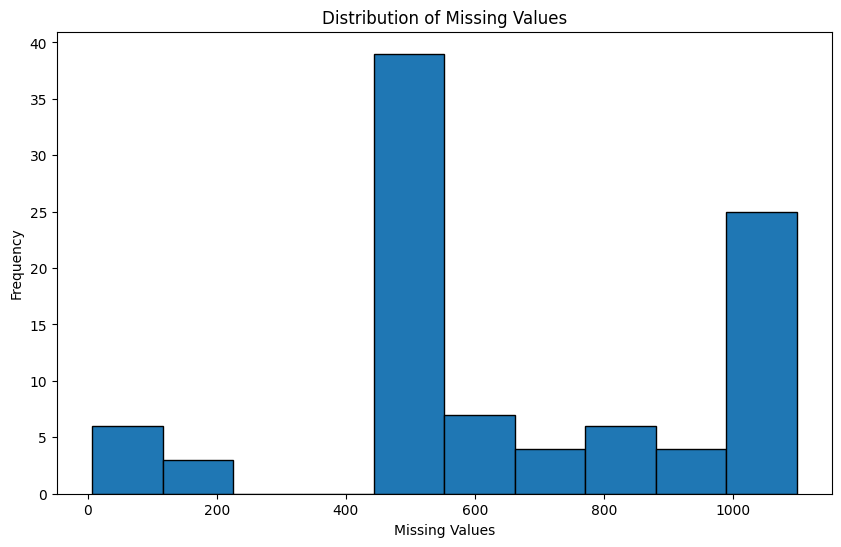

In [5]:
import pandas as pd
columns_with_missing_values = kmeans_df.columns[kmeans_df.isnull().any()].tolist()
columns_with_no_missing_values = kmeans_df.columns[kmeans_df.notnull().all()].tolist()
print(columns_with_missing_values)
# Create a dictionary with column names as keys and number of missing values as values
missing_values = {col: kmeans_df[col].isnull().sum() for col in kmeans_df.columns}

# Create a dataframe from the dictionary
missing_values_df = pd.DataFrame.from_dict(missing_values, orient='index', columns=['Missing Values'])

# Sort the dataframe by the number of missing values in descending order
missing_values_df = missing_values_df.sort_values(by='Missing Values', ascending=False)

# Reset the index of the dataframe
missing_values_df = missing_values_df.reset_index()

# Rename the columns of the dataframe
missing_values_df.columns = ['Column Name', 'Missing Values']

# Print the dataframe
print(missing_values_df)
import matplotlib.pyplot as plt

# Plot the distribution of missing values
plt.figure(figsize=(10, 6))
plt.hist(missing_values_df['Missing Values'], bins=10, edgecolor='black')
plt.xlabel('Missing Values')
plt.ylabel('Frequency')
plt.title('Distribution of Missing Values')
plt.show()

threshold = 980
filtered_variables = missing_values_df[missing_values_df['Missing Values'] <= threshold]['Column Name'].tolist()


In [6]:
len(filtered_variables)

69

In [7]:
import numpy as np

# Calculate the 95th percentile of missing values
missing_values_threshold = np.percentile(missing_values_df['Missing Values'], 95)

# Filter out variables with missing values above the threshold
filtered_variables = missing_values_df[missing_values_df['Missing Values'] <= missing_values_threshold]['Column Name'].tolist()
len(filtered_variables)

89

In [8]:
# Calculate the percentage of missing values for each variable
missing_percentage = kmeans_df.isnull().mean() * 100

# Filter out variables with more than 40% missing values
filtered_variables = missing_percentage[missing_percentage <= 40].index.tolist()
len(filtered_variables)

9

In [9]:
filtered_kmeans_df = kmeans_df[filtered_variables]
filtered_kmeans_df

,Beta\nIn the last 7 D_avg_score_weighted,Book Value per Share\n(USD)\nIn the last 7 FY_avg_score_weighted,Community Score\nIn the last 7 FY_avg_score_weighted,ESG Controversies Score Grade\nIn the last 7 FY_avg_score_weighted,Fleet CO2 Emissions Score\nIn the last 7 FY_avg_score_weighted,Fleet Fuel Consumption Score\nIn the last 7 FY_avg_score_weighted,Management Score Grade\nIn the last 7 FY_avg_score_weighted,Resource Reduction Policy Score\nIn the last 7 FY_avg_score_weighted,Sustainable Building Products Score\nIn the last 7 FY_avg_score_weighted
0,0.000809,0.039352,2339626.489048,0.00016,0.000184,-0.00015,0.031644,0.000154,0.000076
1,0.00272,0.002974,746913.927786,0.00015,0.000851,-0.000118,0.000447,0.00023,0.000166
2,0.001855,0.027048,3166826.111983,0.000514,0.000268,0.000025,0.015124,0.000089,0.000049
3,0.001227,0.036313,2087599.783359,0.000274,0.000266,0.000168,0.015803,0.000122,0.000039
4,0.000797,0.010047,5218690.315018,0.000121,0.000163,-0.000034,0.02482,0.000066,0.000063
...,...,...,...,...,...,...,...,...,...
1094,0.001108,0.000014,1735244.139194,0.000295,0.000483,-0.000634,0.000003,0.000147,0.000091
1095,0.001088,0.013681,145391.679749,0.000276,0.000296,-0.000377,0.009741,0.000126,0.00007
1096,0.000456,0.015511,213692.613291,0.000197,0.000284,-0.000057,0.014235,0.000089,0.000052
1097,0.000727,0.001872,354246.62899,NaN,NaN,NaN,0.003587,NaN,0.000095


In [10]:
filtered_kmeans_df.fillna(0, inplace=True)
from sklearn.cluster import KMeans
kmeans = KMeans(n_clusters=40, random_state=42)
kmeans.fit(filtered_kmeans_df)
filtered_kmeans_df["cluster"]= kmeans.labels_
filtered_kmeans_df

C:\Users\Coco\AppData\Local\Temp\ipykernel_8944\1198333111.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  filtered_kmeans_df.fillna(0, inplace=True)
C:\Users\Coco\AppData\Local\Temp\ipykernel_8944\1198333111.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_kmeans_df.fillna(0, inplace=True)
C:\Users\Coco\AppData\Local\Temp\ipykernel_8944\1198333111.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-

,Beta\nIn the last 7 D_avg_score_weighted,Book Value per Share\n(USD)\nIn the last 7 FY_avg_score_weighted,Community Score\nIn the last 7 FY_avg_score_weighted,ESG Controversies Score Grade\nIn the last 7 FY_avg_score_weighted,Fleet CO2 Emissions Score\nIn the last 7 FY_avg_score_weighted,Fleet Fuel Consumption Score\nIn the last 7 FY_avg_score_weighted,Management Score Grade\nIn the last 7 FY_avg_score_weighted,Resource Reduction Policy Score\nIn the last 7 FY_avg_score_weighted,Sustainable Building Products Score\nIn the last 7 FY_avg_score_weighted,cluster
0,0.000809,0.039352,2.339626e+06,0.000160,0.000184,-0.000150,0.031644,0.000154,0.000076,31
1,0.002720,0.002974,7.469139e+05,0.000150,0.000851,-0.000118,0.000447,0.000230,0.000166,23
2,0.001855,0.027048,3.166826e+06,0.000514,0.000268,0.000025,0.015124,0.000089,0.000049,10
3,0.001227,0.036313,2.087600e+06,0.000274,0.000266,0.000168,0.015803,0.000122,0.000039,6
4,0.000797,0.010047,5.218690e+06,0.000121,0.000163,-0.000034,0.024820,0.000066,0.000063,35
...,...,...,...,...,...,...,...,...,...,...
1094,0.001108,0.000014,1.735244e+06,0.000295,0.000483,-0.000634,0.000003,0.000147,0.000091,19
1095,0.001088,0.013681,1.453917e+05,0.000276,0.000296,-0.000377,0.009741,0.000126,0.000070,22
1096,0.000456,0.015511,2.136926e+05,0.000197,0.000284,-0.000057,0.014235,0.000089,0.000052,39
1097,0.000727,0.001872,3.542466e+05,0.000000,0.000000,0.000000,0.003587,0.000000,0.000095,15


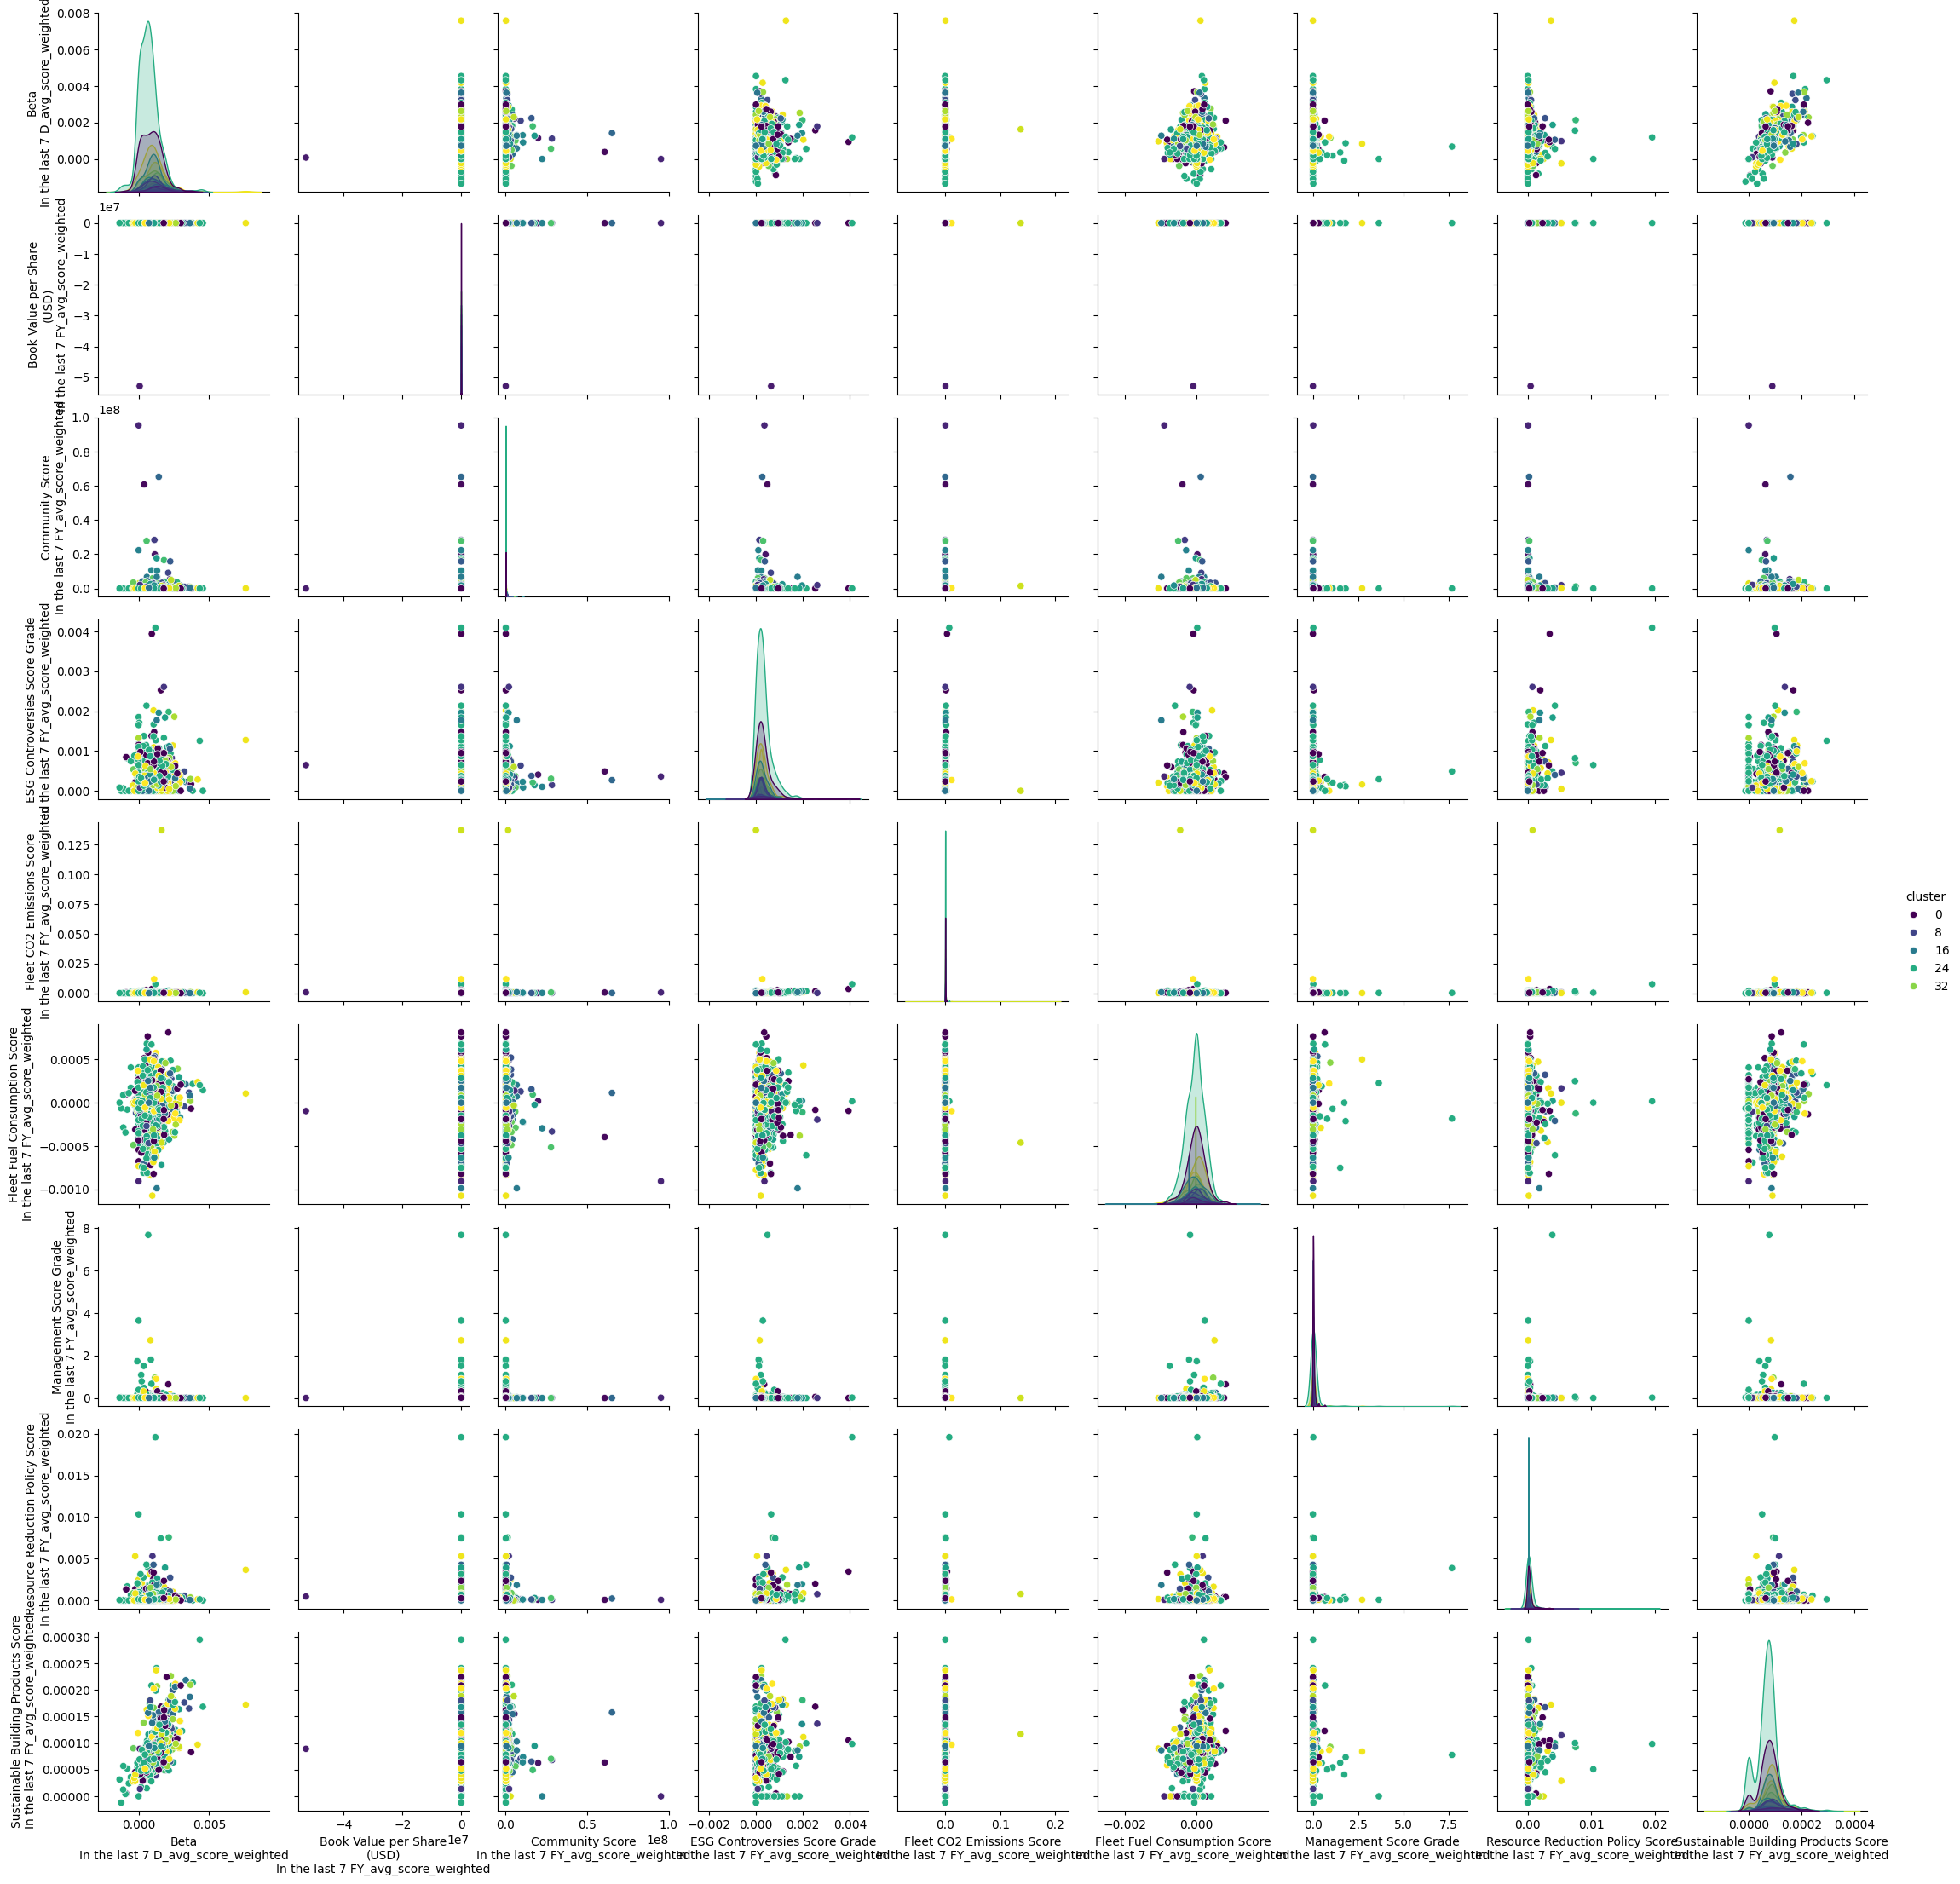

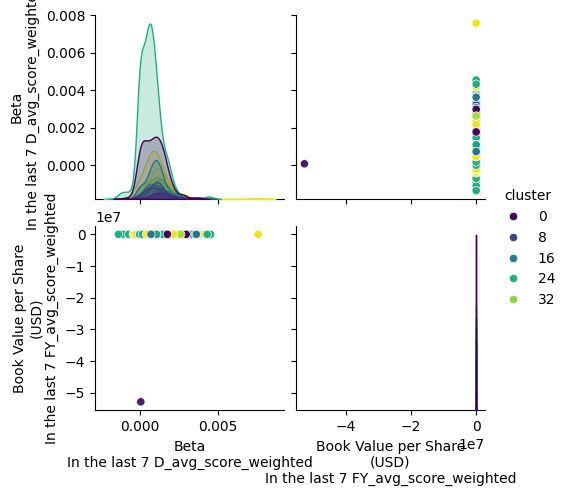

In [11]:
import seaborn as sns

# Create a pairplot of the filtered dataframe, colored by the cluster labels
sns.pairplot(filtered_kmeans_df, hue='cluster', vars=filtered_kmeans_df.columns[:-1], palette='viridis')
sns.pairplot(filtered_kmeans_df, hue='cluster', vars=filtered_kmeans_df.columns[:2], palette='viridis')


In [12]:
filtered_kmeans_df["cluster"].value_counts()

cluster
24    352
0     162
38    107
22     70
39     63
34     50
32     41
23     35
15     33
9      28
12     28
33     21
26     13
6      12
36     12
19     12
10      8
31      7
14      5
20      5
30      5
25      4
37      4
16      3
18      2
29      2
35      2
21      1
8       1
2       1
7       1
27      1
1       1
5       1
17      1
11      1
13      1
4       1
3       1
28      1
Name: count, dtype: int64

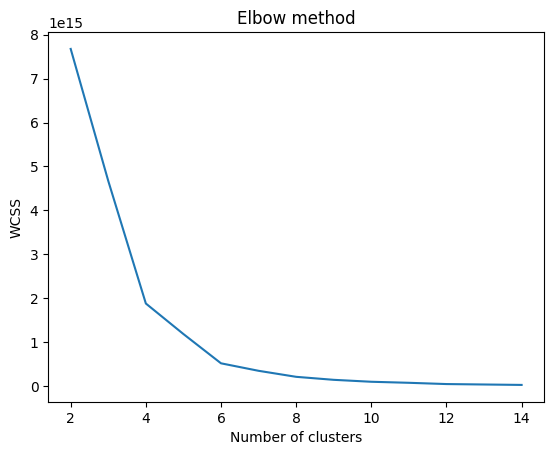

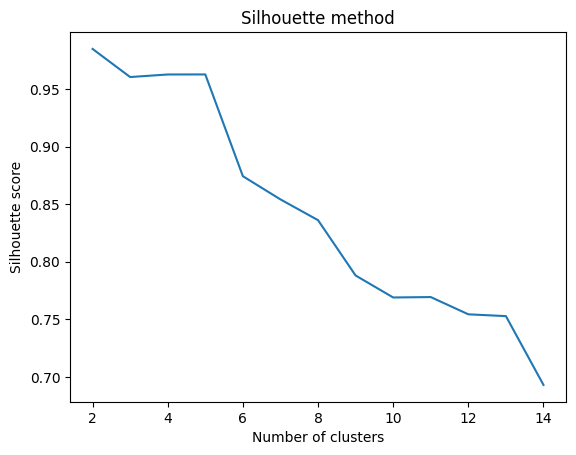

In [13]:
from sklearn.cluster import KMeans
from sklearn import metrics  # Add this line to import the metrics module
import matplotlib.pyplot as plt

# Define a range of possible values for k
k_range = range(2, 15)

# Compute WCSS for each value of k
wcss = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(filtered_kmeans_df)
    wcss.append(kmeans.inertia_)

# Plot the WCSS values against k
plt.plot(k_range, wcss)
plt.title('Elbow method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

# Compute silhouette scores for each value of k
silhouette_scores = []
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(filtered_kmeans_df)
    labels = kmeans.labels_
    silhouette_score = metrics.silhouette_score(filtered_kmeans_df, labels)
    silhouette_scores.append(silhouette_score)

# Plot the silhouette scores against k
plt.plot(k_range, silhouette_scores)
plt.title('Silhouette method')
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
plt.show()


In [14]:
filtered_kmeans_df["cluster"].value_counts()
filtered_kmeans_df[filtered_kmeans_df["cluster"] == 5]


,Beta\nIn the last 7 D_avg_score_weighted,Book Value per Share\n(USD)\nIn the last 7 FY_avg_score_weighted,Community Score\nIn the last 7 FY_avg_score_weighted,ESG Controversies Score Grade\nIn the last 7 FY_avg_score_weighted,Fleet CO2 Emissions Score\nIn the last 7 FY_avg_score_weighted,Fleet Fuel Consumption Score\nIn the last 7 FY_avg_score_weighted,Management Score Grade\nIn the last 7 FY_avg_score_weighted,Resource Reduction Policy Score\nIn the last 7 FY_avg_score_weighted,Sustainable Building Products Score\nIn the last 7 FY_avg_score_weighted,cluster
191,0.002223,0.00036,5.424527e+06,0.000331,0.000337,0.000139,0.001482,0.000128,0.000155,5


In [15]:
# Filter out the rows belonging to cluster 5
cluster5_df = filtered_kmeans_df[filtered_kmeans_df['cluster'] == 5]

# Remove the rows belonging to cluster 5 from filtered_kmeans_df
filtered_kmeans_df = filtered_kmeans_df.drop(cluster5_df.index)
filtered_kmeans_df


,Beta\nIn the last 7 D_avg_score_weighted,Book Value per Share\n(USD)\nIn the last 7 FY_avg_score_weighted,Community Score\nIn the last 7 FY_avg_score_weighted,ESG Controversies Score Grade\nIn the last 7 FY_avg_score_weighted,Fleet CO2 Emissions Score\nIn the last 7 FY_avg_score_weighted,Fleet Fuel Consumption Score\nIn the last 7 FY_avg_score_weighted,Management Score Grade\nIn the last 7 FY_avg_score_weighted,Resource Reduction Policy Score\nIn the last 7 FY_avg_score_weighted,Sustainable Building Products Score\nIn the last 7 FY_avg_score_weighted,cluster
0,0.000809,0.039352,2.339626e+06,0.000160,0.000184,-0.000150,0.031644,0.000154,0.000076,31
1,0.002720,0.002974,7.469139e+05,0.000150,0.000851,-0.000118,0.000447,0.000230,0.000166,23
2,0.001855,0.027048,3.166826e+06,0.000514,0.000268,0.000025,0.015124,0.000089,0.000049,10
3,0.001227,0.036313,2.087600e+06,0.000274,0.000266,0.000168,0.015803,0.000122,0.000039,6
4,0.000797,0.010047,5.218690e+06,0.000121,0.000163,-0.000034,0.024820,0.000066,0.000063,35
...,...,...,...,...,...,...,...,...,...,...
1094,0.001108,0.000014,1.735244e+06,0.000295,0.000483,-0.000634,0.000003,0.000147,0.000091,19
1095,0.001088,0.013681,1.453917e+05,0.000276,0.000296,-0.000377,0.009741,0.000126,0.000070,22
1096,0.000456,0.015511,2.136926e+05,0.000197,0.000284,-0.000057,0.014235,0.000089,0.000052,39
1097,0.000727,0.001872,3.542466e+05,0.000000,0.000000,0.000000,0.003587,0.000000,0.000095,15


In [16]:

# Run k-means on the filtered dataframe
kmeans = KMeans(n_clusters=20, random_state=42)
kmeans.fit(filtered_kmeans_df)
filtered_kmeans_df['cluster'] = kmeans.labels_
filtered_kmeans_df


,Beta\nIn the last 7 D_avg_score_weighted,Book Value per Share\n(USD)\nIn the last 7 FY_avg_score_weighted,Community Score\nIn the last 7 FY_avg_score_weighted,ESG Controversies Score Grade\nIn the last 7 FY_avg_score_weighted,Fleet CO2 Emissions Score\nIn the last 7 FY_avg_score_weighted,Fleet Fuel Consumption Score\nIn the last 7 FY_avg_score_weighted,Management Score Grade\nIn the last 7 FY_avg_score_weighted,Resource Reduction Policy Score\nIn the last 7 FY_avg_score_weighted,Sustainable Building Products Score\nIn the last 7 FY_avg_score_weighted,cluster
0,0.000809,0.039352,2.339626e+06,0.000160,0.000184,-0.000150,0.031644,0.000154,0.000076,13
1,0.002720,0.002974,7.469139e+05,0.000150,0.000851,-0.000118,0.000447,0.000230,0.000166,0
2,0.001855,0.027048,3.166826e+06,0.000514,0.000268,0.000025,0.015124,0.000089,0.000049,19
3,0.001227,0.036313,2.087600e+06,0.000274,0.000266,0.000168,0.015803,0.000122,0.000039,10
4,0.000797,0.010047,5.218690e+06,0.000121,0.000163,-0.000034,0.024820,0.000066,0.000063,11
...,...,...,...,...,...,...,...,...,...,...
1094,0.001108,0.000014,1.735244e+06,0.000295,0.000483,-0.000634,0.000003,0.000147,0.000091,10
1095,0.001088,0.013681,1.453917e+05,0.000276,0.000296,-0.000377,0.009741,0.000126,0.000070,14
1096,0.000456,0.015511,2.136926e+05,0.000197,0.000284,-0.000057,0.014235,0.000089,0.000052,14
1097,0.000727,0.001872,3.542466e+05,0.000000,0.000000,0.000000,0.003587,0.000000,0.000095,18


In [17]:
filtered_kmeans_df["cluster"].value_counts()

cluster
4     582
14    215
18     92
0      69
16     51
10     32
13     14
19     14
6       9
11      6
9       3
7       2
17      2
3       1
8       1
1       1
15      1
12      1
5       1
2       1
Name: count, dtype: int64

In [18]:
# Combine the new clustering results with the original cluster 5 data
filtered_kmeans_df = pd.concat([filtered_kmeans_df, cluster5_df], ignore_index=True)
filtered_kmeans_df

,Beta\nIn the last 7 D_avg_score_weighted,Book Value per Share\n(USD)\nIn the last 7 FY_avg_score_weighted,Community Score\nIn the last 7 FY_avg_score_weighted,ESG Controversies Score Grade\nIn the last 7 FY_avg_score_weighted,Fleet CO2 Emissions Score\nIn the last 7 FY_avg_score_weighted,Fleet Fuel Consumption Score\nIn the last 7 FY_avg_score_weighted,Management Score Grade\nIn the last 7 FY_avg_score_weighted,Resource Reduction Policy Score\nIn the last 7 FY_avg_score_weighted,Sustainable Building Products Score\nIn the last 7 FY_avg_score_weighted,cluster
0,0.000809,0.039352,2.339626e+06,0.000160,0.000184,-0.000150,0.031644,0.000154,0.000076,13
1,0.002720,0.002974,7.469139e+05,0.000150,0.000851,-0.000118,0.000447,0.000230,0.000166,0
2,0.001855,0.027048,3.166826e+06,0.000514,0.000268,0.000025,0.015124,0.000089,0.000049,19
3,0.001227,0.036313,2.087600e+06,0.000274,0.000266,0.000168,0.015803,0.000122,0.000039,10
4,0.000797,0.010047,5.218690e+06,0.000121,0.000163,-0.000034,0.024820,0.000066,0.000063,11
...,...,...,...,...,...,...,...,...,...,...
1094,0.001088,0.013681,1.453917e+05,0.000276,0.000296,-0.000377,0.009741,0.000126,0.000070,14
1095,0.000456,0.015511,2.136926e+05,0.000197,0.000284,-0.000057,0.014235,0.000089,0.000052,14
1096,0.000727,0.001872,3.542466e+05,0.000000,0.000000,0.000000,0.003587,0.000000,0.000095,18
1097,0.001778,0.038850,4.591955e+04,0.000234,0.000357,-0.000189,0.015589,0.000252,0.000064,4


### Different clustering techniques

In [70]:
from sklearn.cluster import DBSCAN

# Compute DBSCAN clustering with eps=0.5 and min_samples=5
dbscan = DBSCAN(eps=0.5, min_samples=5)
dbscan.fit(filtered_kmeans_df)

# Get the cluster labels
labels = dbscan.labels_

# Get the number of clusters
n_clusters = len(set(labels)) - (1 if -1 in labels else 0)


1


In [72]:
from sklearn.mixture import GaussianMixture

# Fit a Gaussian mixture model with 3 components
gmm = GaussianMixture(n_components=3)
gmm.fit(filtered_kmeans_df)

# Get the cluster labels
labels = gmm.predict(filtered_kmeans_df)

# Get the number of clusters
n_clusters = gmm.n_components


In [73]:
print(n_clusters)

3


In [75]:
from sklearn.cluster import AgglomerativeClustering

# Compute agglomerative clustering with Ward's method and n_clusters=3
agglomerative = AgglomerativeClustering(n_clusters=3, linkage='ward')
agglomerative.fit(filtered_kmeans_df)

# Get the cluster labels
labels = agglomerative.labels_

# Get the number of clusters
n_clusters = agglomerative.n_clusters_
print(n_clusters)

3


In [79]:
filtered_kmeans_df["cluster"]

0       5
1       0
2       5
3       0
4       5
       ..
1094    0
1095    0
1096    0
1097    0
1098    0
Name: cluster, Length: 1099, dtype: int32

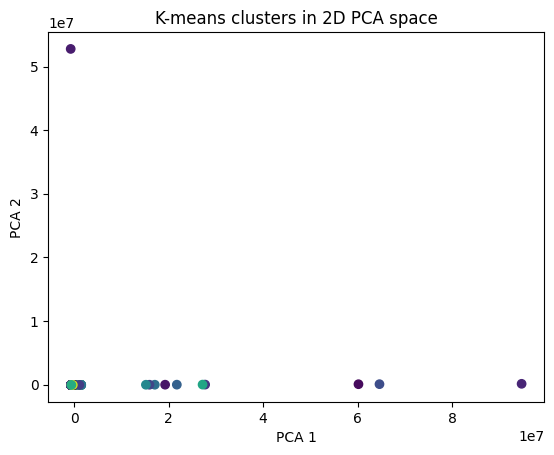

In [119]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

#filtered_kmeans_df.fillna(0, inplace=True)

# Fit the PCA model to the data and transform it to 2D
pca = PCA(n_components=2)
pca_data = pca.fit_transform(filtered_kmeans_df)

# Plot the data points, colored by their cluster labels
plt.scatter(pca_data[:, 0], pca_data[:, 1], c=filtered_kmeans_df["cluster"])
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('K-means clusters in 2D PCA space')
plt.show()


### New code to deal with missing values

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the Excel file into a DataFrame
df = pd.read_excel('FULL ESG DATA 25.03.xlsx', header=[0, 1],
                          skiprows=[2,2],
                            #nrows=10
                            )

# Print the DataFrame
df


Identifier                  Company Name  \
     Unnamed: 0_level_1            Unnamed: 1_level_1   
0                110448  British American Tobacco plc   
1                204386                        CGG SA   
2                225313            Credit Agricole SA   
3                251525              Deutsche Bank AG   
4                251566           Deutsche Telekom AG   
...                 ...                           ...   
1094             94846C                Rizzo Group AB   
1095             65527N              Nokian Tyres plc   
1096             86466Q                 Suedzucker AG   
1097             31529L                  Ferretti SpA   
1098             95074Q                 Wereldhave NV   

     ESG Score Grade\nIn the last 7 FY                                \
                                   FY0 FY-1 FY-2 FY-3 FY-4 FY-5 FY-6   
0                                    A   A+   A+    A    A   A-   A-   
1                                   A-   B+   B+   B+   B+   B+    B   
2                                    B   B+   B+    B   B+    B    B   
3                                    A   A-    A    A   A-   A-   A-   
4                                   A-    A    A   A-   A-   A-   A-   
...                                ...  ...  ...  ...  ...  ...  ...   
1094                               NaN  NaN  NaN  NaN  NaN  NaN  NaN   
1095                                 B    B    B    B    B    B   C+   
1096                                 B    B    B   B-   C+   C+   C+   
1097                               NaN  NaN  NaN  NaN  NaN  NaN  NaN   
1098                                B-   B-    B   B-    B    B   B-   

     ESG Combined Score Grade\nIn the last 7 FY  ...  \
                                            FY0  ...   
0                                            C+  ...   
1                                            A-  ...   
2                                            C+  ...   
3                                            C+  ...   
4                                            A-  ...   
...                                         ...  ...   
1094                                        NaN  ...   
1095                                          B  ...   
1096                                          B  ...   
1097                                        NaN  ...   
1098                                         B-  ...   

     ESG Combined Score\nIn the last 7 FY                        \
                                     FY-4       FY-5       FY-6   
0                               88.927167  61.328028  83.040627   
1                               69.567919  68.630067  66.396276   
2                               71.567016  41.135701  44.962708   
3                               41.051302  41.198827  38.818330   
4                               66.479803  76.985986  48.985011   
...                                   ...        ...        ...   
1094                                  NaN        NaN        NaN   
1095                            52.508811  58.782984  47.952315   
1096                            48.211760  44.367919  48.238682   
1097                                  NaN        NaN        NaN   
1098                            64.984199  61.522375  56.925180   

     ESG Controversies Score\nIn the last 7 FY                          \
                                           FY0        FY-1        FY-2   
0                                     4.729730   27.272727   14.473684   
1                                   100.000000  100.000000  100.000000   
2                                    26.699029   91.477273   45.000000   
3                                     2.743902    5.339806    1.704545   
4                                    79.166667   19.512195  100.000000   
...                                        ...         ...         ...   
1094                                       NaN         NaN         NaN   
1095                                 59.166667  100.000000   79.729

In [20]:
dfs = []
for col_name in df.columns.levels[0]:
    current_df = df.loc[:, (col_name, slice(None))]
    if current_df.dtypes[0] != 'object': # check if the column has numeric data
        current_df['average_score'] = None
        current_df['weight'] = None
        total_years = 0
        for index, row in current_df.iterrows():
            count = row.count()
            if count > 0:
                avg = row.sum() / count
                current_df.at[index, 'average_score'] = avg

            filtered_columns = [col for col in current_df.columns if 'FY' or 'D' in col[1]]
            available_years = row[filtered_columns].count()
            total_years += available_years

        for index, row in current_df.iterrows():
            filtered_columns = [col for col in current_df.columns if 'FY' or 'D' in col[1]]
            available_years = row[filtered_columns].count()
            current_df.at[index, 'weight'] = available_years / total_years

        current_df["avg_score_weighted"] = current_df["average_score"] * current_df["weight"]

        # remove outliers
        z_scores = (current_df["avg_score_weighted"] - current_df["avg_score_weighted"].mean()) / current_df["avg_score_weighted"].std()
        current_df = current_df[(z_scores < 2) & (z_scores > -2)]

        # drop rows with all zero values for a specific variable
        current_df = current_df.loc[(current_df != 0).any(axis=1)]

        dfs.append(current_df)

# randomly select 3 dataframes from the list
selected_dfs = random.sample(dfs, 3)

# print the selected dataframes
for df in selected_dfs:
    print(df)


C:\Users\Coco\AppData\Local\Temp\ipykernel_8944\1020565357.py:4: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  if current_df.dtypes[0] != 'object': # check if the column has numeric data
C:\Users\Coco\AppData\Local\Temp\ipykernel_8944\1020565357.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  current_df['average_score'] = None
C:\Users\Coco\AppData\Local\Temp\ipykernel_8944\1020565357.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in th

     Renewable Energy Use Ratio Score\nIn the last 7 FY                        \
                                                    FY0       FY-1       FY-2   
0                                             70.500000  71.348315  75.000000   
2                                                   NaN        NaN        NaN   
3                                             57.666667  56.250000  43.367347   
4                                             85.593220  89.166667  62.500000   
6                                             88.461538  78.571429  75.000000   
...                                                 ...        ...        ...   
1078                                          95.731707  86.718750  90.000000   
1082                                          47.520661  49.519231  45.061728   
1086                                          70.652174  73.000000  52.857143   
1095                                          64.024390  77.343750  68.181818   
1096                        

C:\Users\Coco\AppData\Local\Temp\ipykernel_8944\1020565357.py:23: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  current_df["avg_score_weighted"] = current_df["average_score"] * current_df["weight"]


In [21]:
kmeans_df = pd.DataFrame()
for i,df in enumerate(dfs):
    weighted_avg_score = df.xs('avg_score_weighted', level=0, axis=1)
    weighted_avg_score.columns = [f"{df.columns.levels[0][i]}_avg_score_weighted" ]
    kmeans_df = pd.concat([kmeans_df, weighted_avg_score], axis=1)
kmeans_df

,Agrochemical Products Score\nIn the last 7 FY_avg_score_weighted,Animal Testing Score\nIn the last 7 FY_avg_score_weighted,Beta\nIn the last 7 D_avg_score_weighted,Biodiversity Impact Reduction Score\nIn the last 7 FY_avg_score_weighted,Book Value per Share\n(USD)\nIn the last 7 FY_avg_score_weighted,CSR Strategy Score\nIn the last 7 FY_avg_score_weighted,CSR Strategy Score Grade\nIn the last 7 FY_avg_score_weighted,Cement CO2 Equivalents Emission Score\nIn the last 7 FY_avg_score_weighted,Cement Energy Use Score\nIn the last 7 FY_avg_score_weighted,Climate Change Commercial Risks Opportunities Score\nIn the last 7 FY_avg_score_weighted,...,Resource Use Score Grade\nIn the last 7 FY_avg_score_weighted,Self-Reported Environmental Fines Score\nIn the last 7 FY_avg_score_weighted,Shareholders Score\nIn the last 7 FY_avg_score_weighted,Shareholders Score Grade\nIn the last 7 FY_avg_score_weighted,Social Pillar Score\nIn the last 7 FY_avg_score_weighted,Social Pillar Score Grade\nIn the last 7 FY_avg_score_weighted,Staff Transportation Impact Reduction Score\nIn the last 7 FY_avg_score_weighted,Sustainable Building Products Score\nIn the last 7 FY_avg_score_weighted,Targets Emissions Score\nIn the last 7 FY_avg_score_weighted,Targets Energy Efficiency Score\nIn the last 7 FY_avg_score_weighted
21,0.0,NaN,0.001561,0.0,0.018741,0.193955,NaN,NaN,0.170264,0.158449,...,0.000734,0.167417,0.189131,NaN,NaN,NaN,NaN,0.000112,0.18796,NaN
45,0.0,NaN,NaN,0.242901,0.077648,0.186684,NaN,NaN,0.17374,0.164608,...,0.000846,0.337599,NaN,0.42427,1.097921,NaN,0.045513,NaN,0.202239,NaN
54,0.0,NaN,0.000846,0.172185,0.03416,0.204883,NaN,NaN,0.17374,0.197878,...,0.001832,0.0,0.0579,0.589053,0.343614,NaN,0.022133,0.000086,0.178923,NaN
113,0.0,NaN,0.000519,0.242901,0.02402,0.170833,NaN,NaN,0.14752,0.148489,...,0.000195,0.0,0.149501,0.076832,NaN,NaN,0.25757,0.000064,0.209916,NaN
212,0.0,NaN,0.001434,0.136867,0.050369,0.183899,NaN,NaN,0.17374,0.216438,...,0.00071,0.0,0.193436,0.903269,NaN,NaN,0.081745,0.000087,0.214086,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
767,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
812,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
815,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
837,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [168]:
kmeans_df.dropna(axis=1, how='all', inplace=True)
kmeans_df

,Agrochemical Products Score\nIn the last 7 FY_avg_score_weighted,Animal Testing Score\nIn the last 7 FY_avg_score_weighted,Beta\nIn the last 7 D_avg_score_weighted,Biodiversity Impact Reduction Score\nIn the last 7 FY_avg_score_weighted,Book Value per Share\n(USD)\nIn the last 7 FY_avg_score_weighted,CSR Strategy Score\nIn the last 7 FY_avg_score_weighted,CSR Strategy Score Grade\nIn the last 7 FY_avg_score_weighted,Cement CO2 Equivalents Emission Score\nIn the last 7 FY_avg_score_weighted,Cement Energy Use Score\nIn the last 7 FY_avg_score_weighted,Climate Change Commercial Risks Opportunities Score\nIn the last 7 FY_avg_score_weighted,...,Resource Use Score Grade\nIn the last 7 FY_avg_score_weighted,Self-Reported Environmental Fines Score\nIn the last 7 FY_avg_score_weighted,Shareholders Score\nIn the last 7 FY_avg_score_weighted,Shareholders Score Grade\nIn the last 7 FY_avg_score_weighted,Social Pillar Score\nIn the last 7 FY_avg_score_weighted,Social Pillar Score Grade\nIn the last 7 FY_avg_score_weighted,Staff Transportation Impact Reduction Score\nIn the last 7 FY_avg_score_weighted,Sustainable Building Products Score\nIn the last 7 FY_avg_score_weighted,Targets Emissions Score\nIn the last 7 FY_avg_score_weighted,Targets Energy Efficiency Score\nIn the last 7 FY_avg_score_weighted
21,0.0,NaN,0.001561,0.0,0.018741,0.193955,NaN,NaN,0.170264,0.158449,...,0.000734,0.167417,0.189131,NaN,NaN,NaN,NaN,0.000112,0.18796,NaN
45,0.0,NaN,NaN,0.242901,0.077648,0.186684,NaN,NaN,0.17374,0.164608,...,0.000846,0.337599,NaN,0.42427,1.097921,NaN,0.045513,NaN,0.202239,NaN
54,0.0,NaN,0.000846,0.172185,0.03416,0.204883,NaN,NaN,0.17374,0.197878,...,0.001832,0.0,0.0579,0.589053,0.343614,NaN,0.022133,0.000086,0.178923,NaN
113,0.0,NaN,0.000519,0.242901,0.02402,0.170833,NaN,NaN,0.14752,0.148489,...,0.000195,0.0,0.149501,0.076832,NaN,NaN,0.25757,0.000064,0.209916,NaN
212,0.0,NaN,0.001434,0.136867,0.050369,0.183899,NaN,NaN,0.17374,0.216438,...,0.00071,0.0,0.193436,0.903269,NaN,NaN,0.081745,0.000087,0.214086,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
767,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
812,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
815,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
837,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [170]:
col = kmeans_df.columns[3]

In [180]:
kmeans_df[col]

21           0.0
45      0.242901
54      0.172185
113     0.242901
212     0.136867
          ...   
767          NaN
812          NaN
815          NaN
837          NaN
1063         NaN
Name: Biodiversity Impact Reduction Score\nIn the last 7 FY_avg_score_weighted, Length: 1094, dtype: object

In [157]:
for i,col in enumerate(kmeans_df.columns):
    print(f"The index is :{i} and the column is: {col}")
    #print(f"Printing the unique values in the column: {kmeans_df[col][i]}")
    kmeans_df[col]

The index is :0 and the column is: Agrochemical Products Score
In the last 7 FY_avg_score_weighted
The index is :1 and the column is: Animal Testing Score
In the last 7 FY_avg_score_weighted
The index is :2 and the column is: Beta
In the last 7 D_avg_score_weighted
The index is :3 and the column is: Biodiversity Impact Reduction Score
In the last 7 FY_avg_score_weighted
The index is :4 and the column is: Book Value per Share
(USD)
In the last 7 FY_avg_score_weighted
The index is :5 and the column is: CSR Strategy Score
In the last 7 FY_avg_score_weighted
The index is :6 and the column is: CSR Strategy Score Grade
In the last 7 FY_avg_score_weighted
The index is :7 and the column is: Cement CO2 Equivalents Emission Score
In the last 7 FY_avg_score_weighted
The index is :8 and the column is: Cement Energy Use Score
In the last 7 FY_avg_score_weighted
The index is :9 and the column is: Climate Change Commercial Risks Opportunities Score
In the last 7 FY_avg_score_weighted
The index is :10

In [186]:
name = kmeans_df.columns[1]
kmeans_df[name]

21      NaN
45      NaN
54      NaN
113     NaN
212     NaN
       ... 
767     NaN
812     NaN
815     NaN
837     NaN
1063    NaN
Name: Animal Testing Score\nIn the last 7 FY_avg_score_weighted, Length: 1094, dtype: object

c:\Users\Coco\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\histograms.py:825: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
c:\Users\Coco\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\histograms.py:826: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


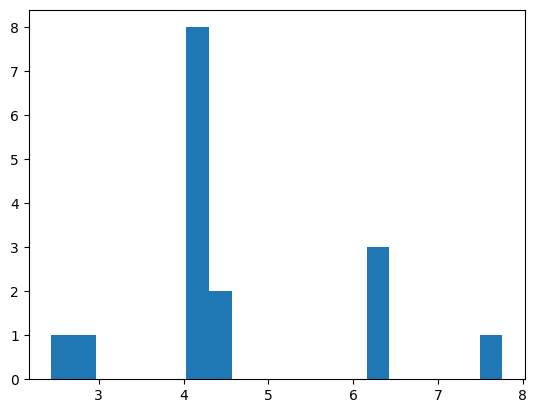

In [187]:
plt.hist(kmeans_df[name], bins=20)
plt.show()

Plotting Agrochemical Products Score
In the last 7 FY_avg_score_weighted
0


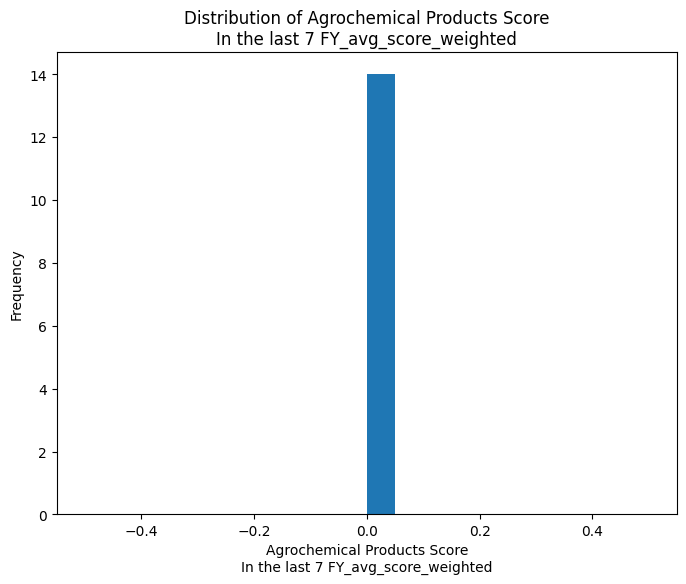

Plotting Animal Testing Score
In the last 7 FY_avg_score_weighted
1


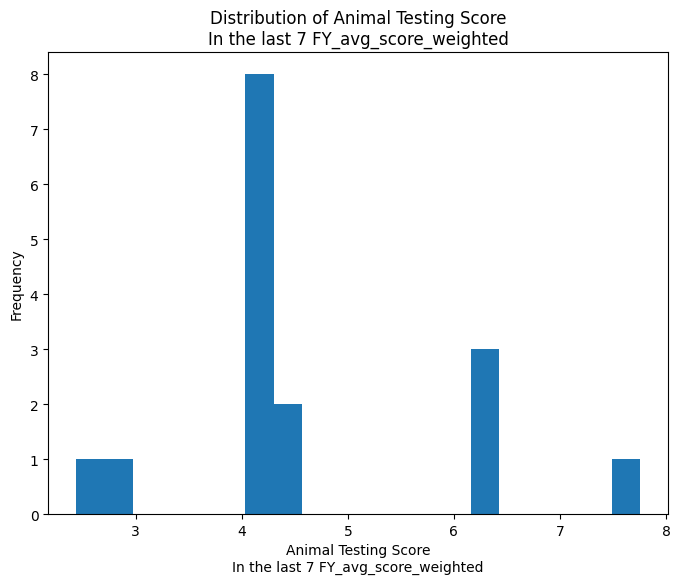

Plotting Beta
In the last 7 D_avg_score_weighted
2


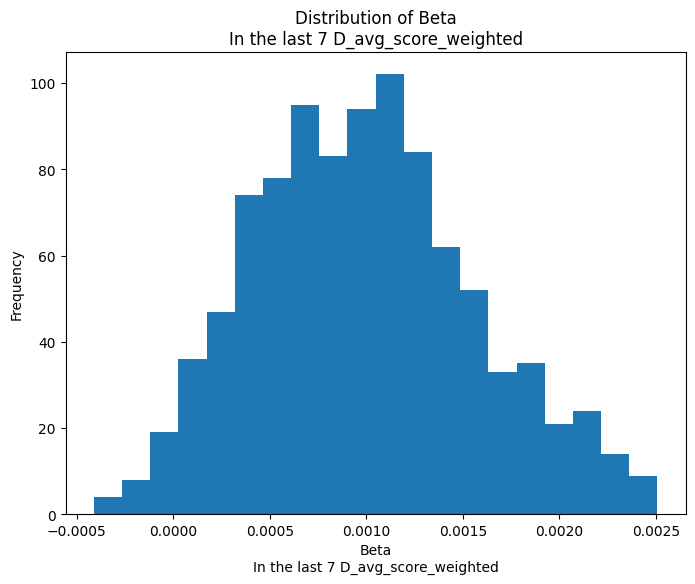

Plotting Biodiversity Impact Reduction Score
In the last 7 FY_avg_score_weighted
3


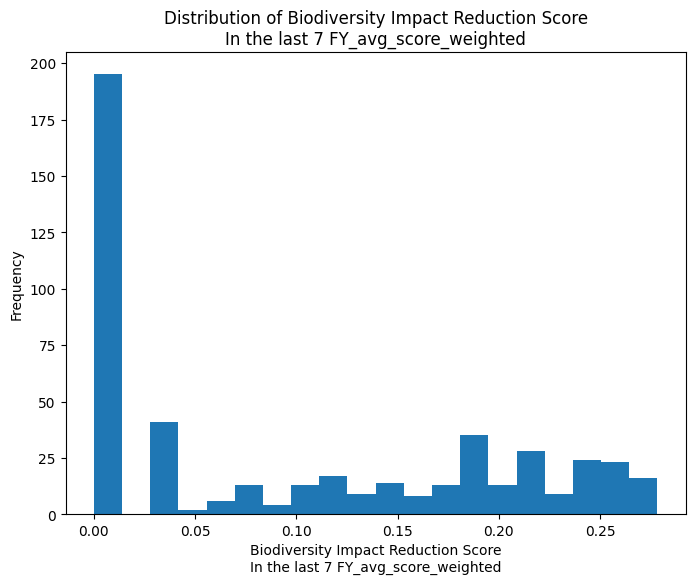

Plotting Book Value per Share
(USD)
In the last 7 FY_avg_score_weighted
4


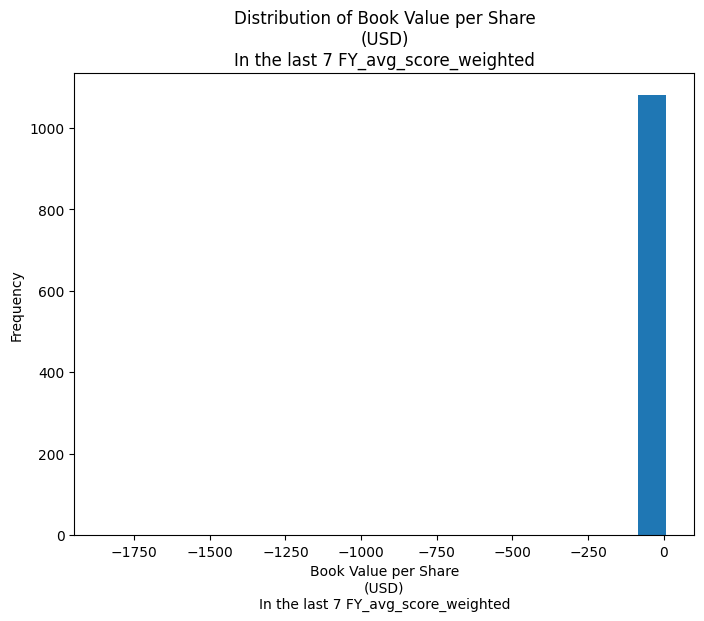

Plotting CSR Strategy Score
In the last 7 FY_avg_score_weighted
5


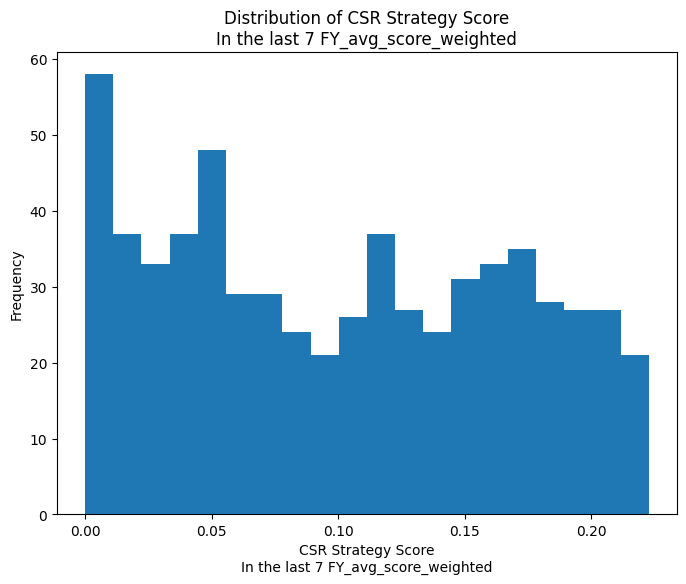

Plotting CSR Strategy Score Grade
In the last 7 FY_avg_score_weighted
6


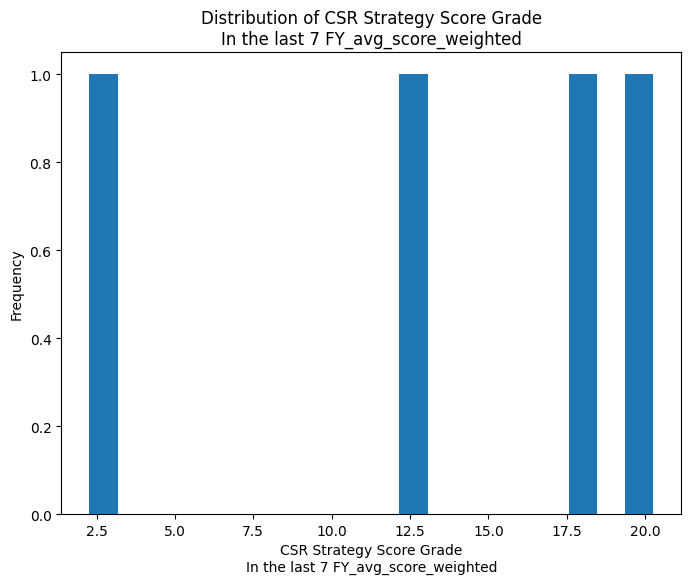

Plotting Cement CO2 Equivalents Emission Score
In the last 7 FY_avg_score_weighted
7


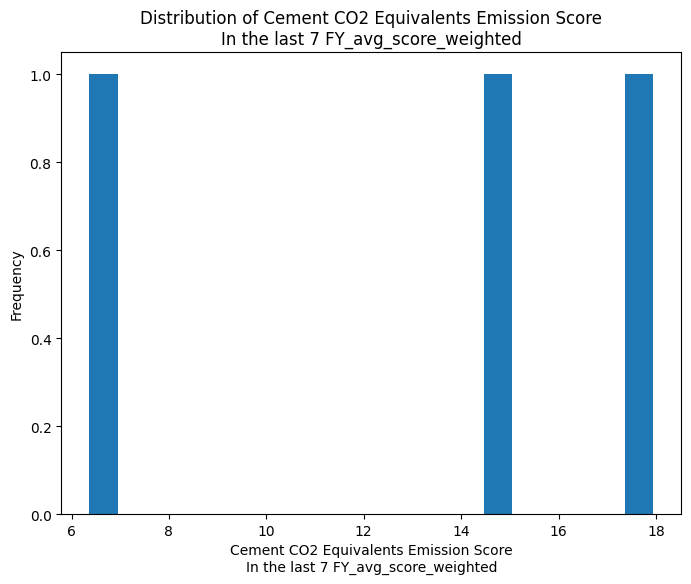

Plotting Cement Energy Use Score
In the last 7 FY_avg_score_weighted
8


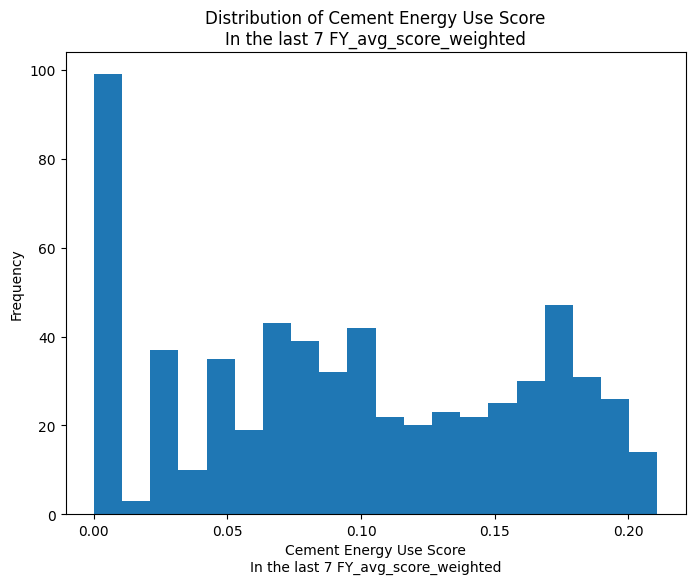

Plotting Climate Change Commercial Risks Opportunities Score
In the last 7 FY_avg_score_weighted
9


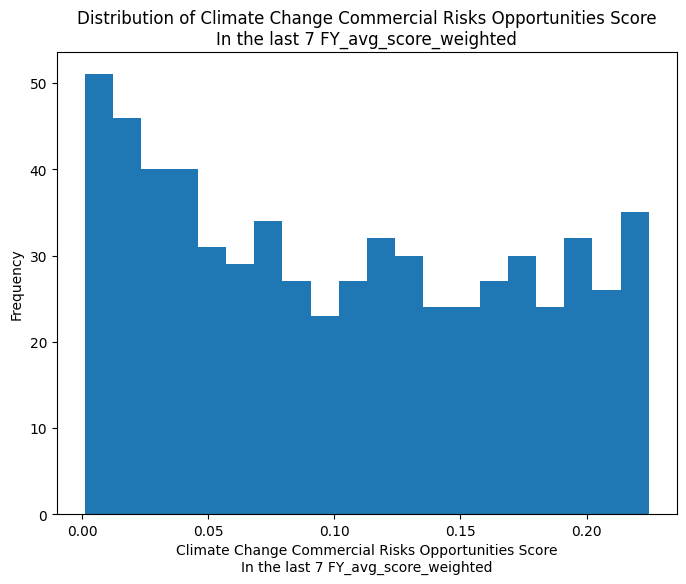

Plotting Community Score
In the last 7 FY_avg_score_weighted
10


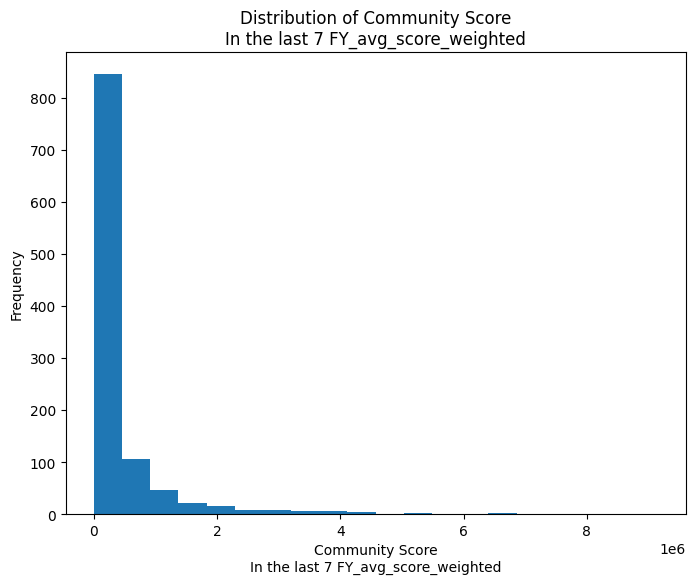

Plotting Community Score Grade
In the last 7 FY_avg_score_weighted
11


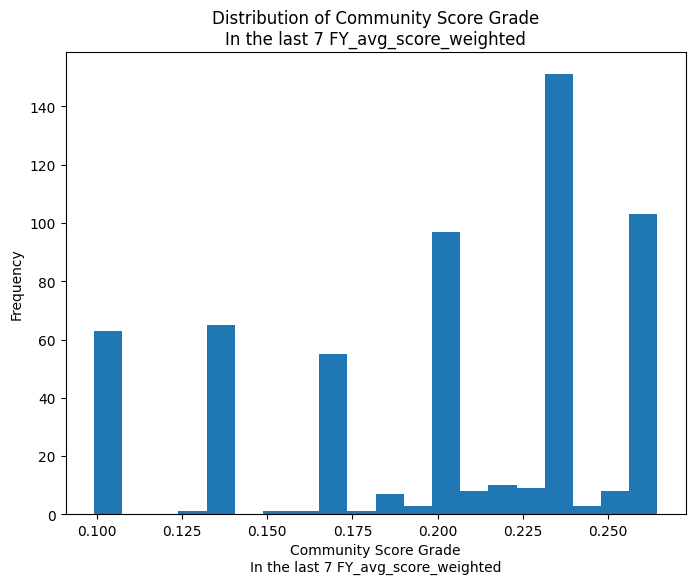

Plotting Company Name_avg_score_weighted
12


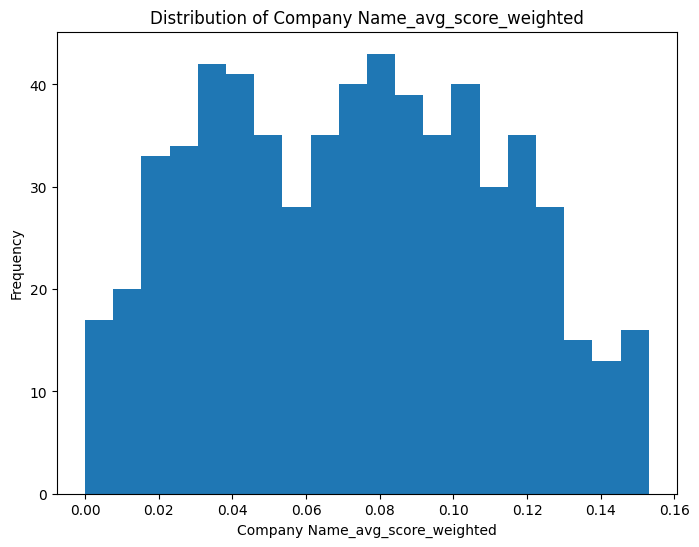

Plotting Company Shares 
In the last 7 D_avg_score_weighted
13


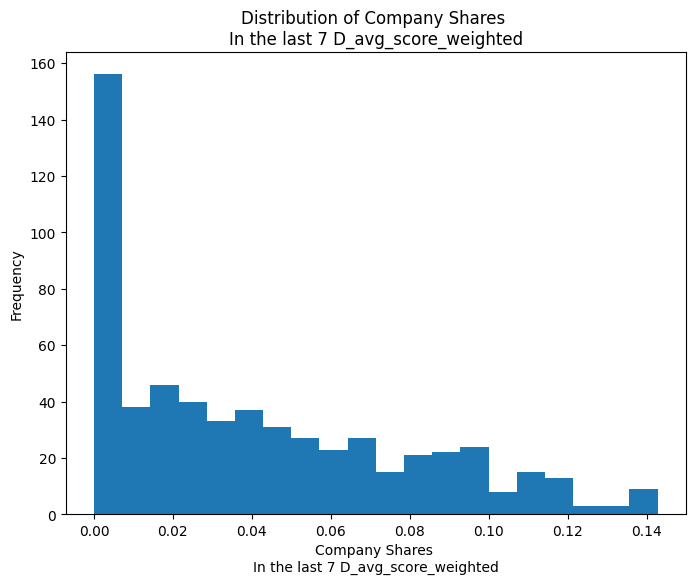

Plotting DIR Controversies Score
In the last 7 FY_avg_score_weighted
14


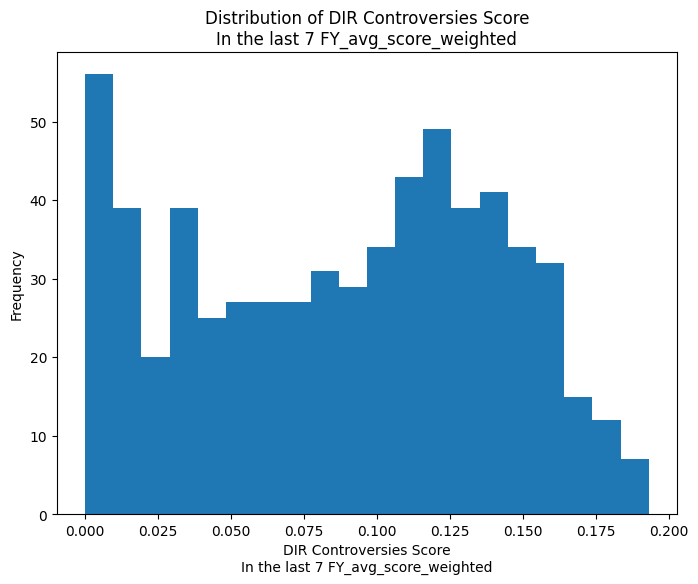

Plotting DIR Diversity Score
In the last 7 FY_avg_score_weighted
15


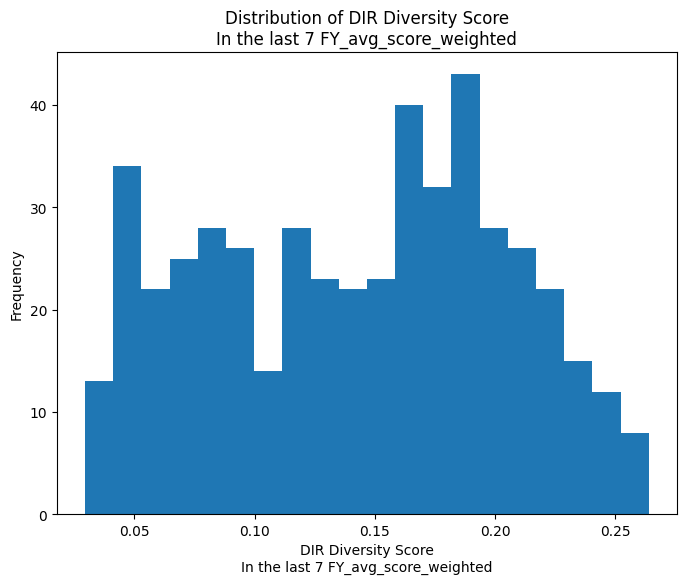

Plotting DIR Inclusion Score
In the last 7 FY_avg_score_weighted
16


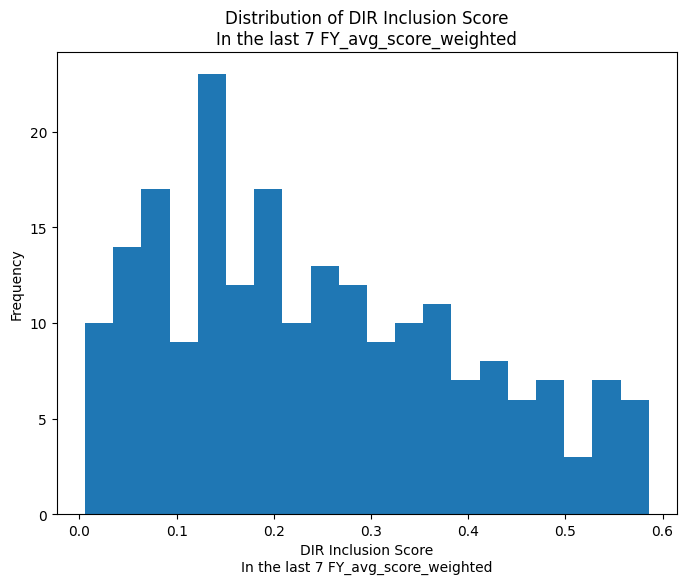

Plotting DIR People Development Score
In the last 7 FY_avg_score_weighted
17


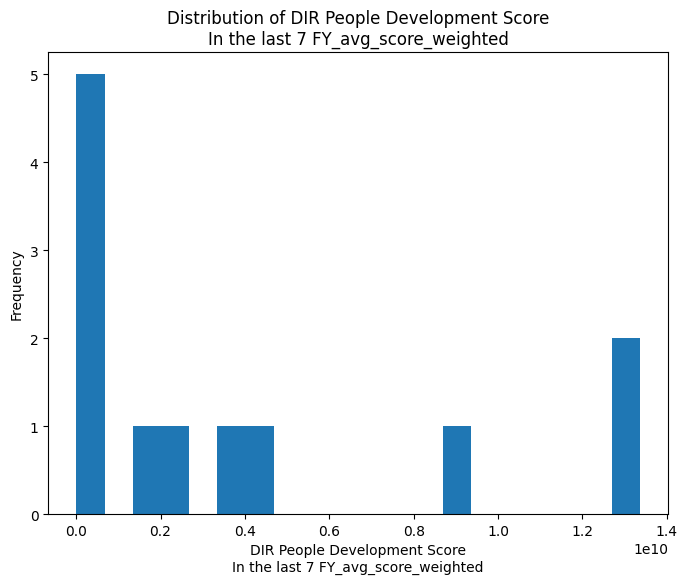

Plotting DIR Score
In the last 7 FY_avg_score_weighted
18


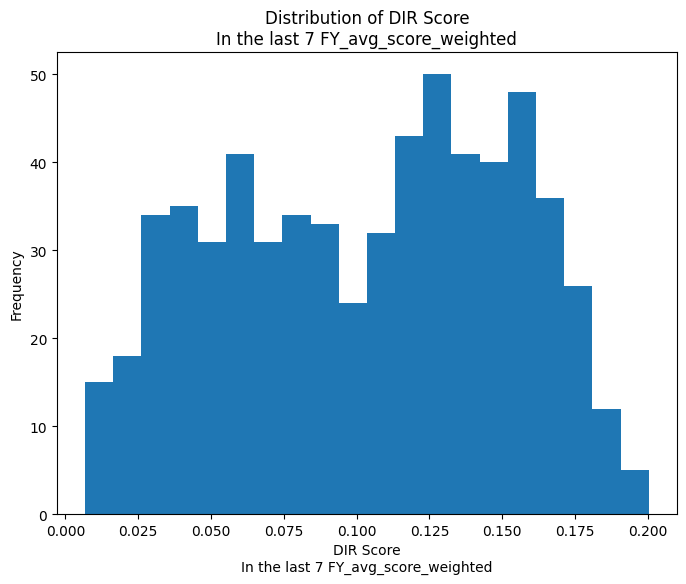

Plotting EMS Certified Percent Score
In the last 7 FY_avg_score_weighted
19


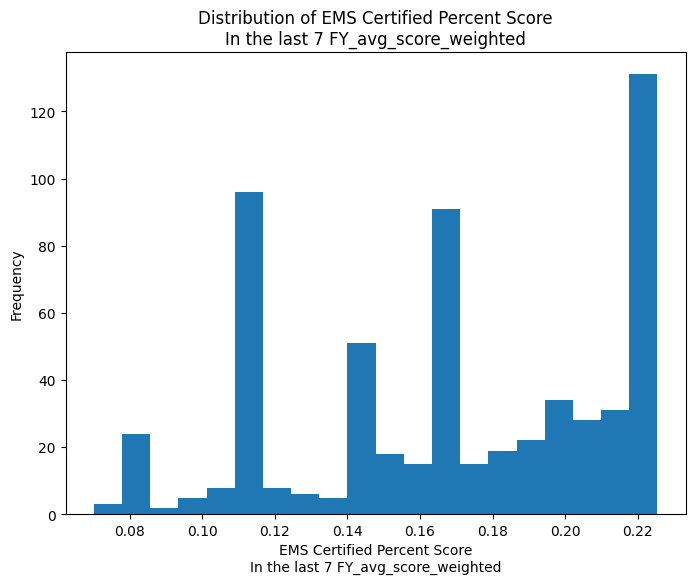

Plotting ESG Assets Under Management
(USD)
In the last 7 FY_avg_score_weighted
20


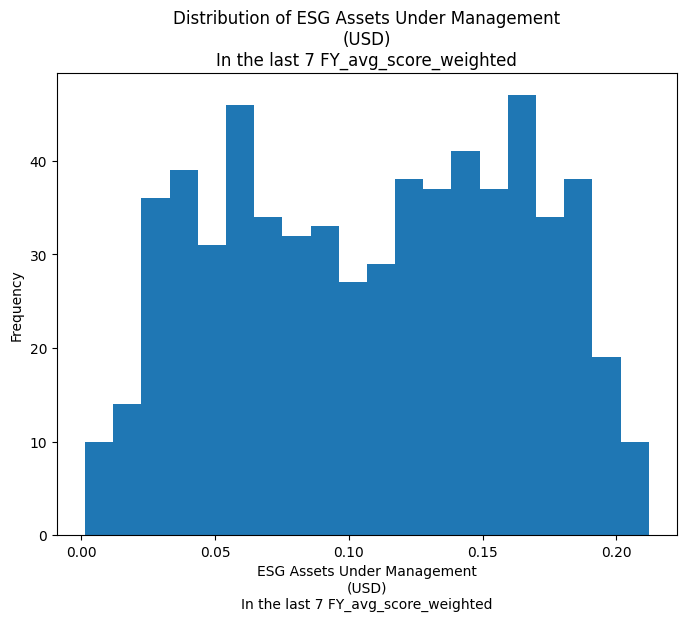

Plotting ESG Combined Score
In the last 7 FY_avg_score_weighted
21


AttributeError: 'float' object has no attribute 'dtype'

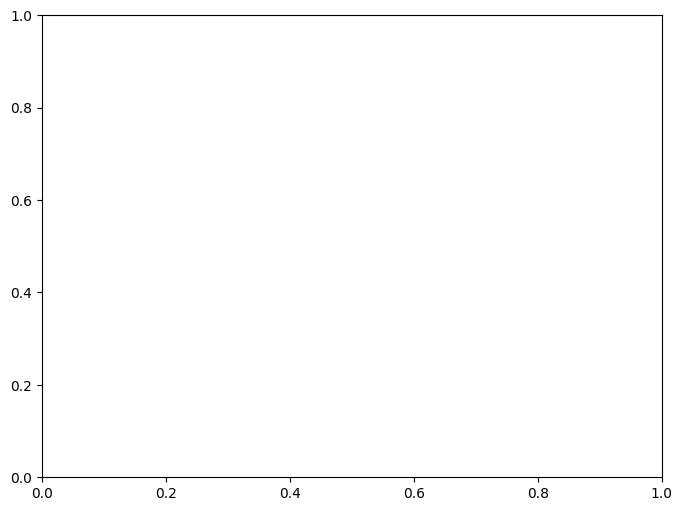

In [23]:
import matplotlib.pyplot as plt
for i,column in enumerate(kmeans_df.columns):
    print(f"Plotting {column}")
    print(i)
    plt.figure(figsize=(8, 6))
    plt.hist(kmeans_df[column], bins=20)
    plt.title(f"Distribution of {column}")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()
"""

# Get the name names from the DataFrame
names = kmeans_df.names

# Plot the distribution of values for each name
for i,name in enumerate(kmeans_df.names):
    plt.figure(figsize=(8, 6))
    plt.hist(kmeans_df[name], bins=20)
    plt.title(f"Distribution of {name}")
    plt.xlabel(name)
    plt.ylabel("Frequency")
    plt.show()
"""

c:\Users\Coco\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\histograms.py:825: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
c:\Users\Coco\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\histograms.py:826: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


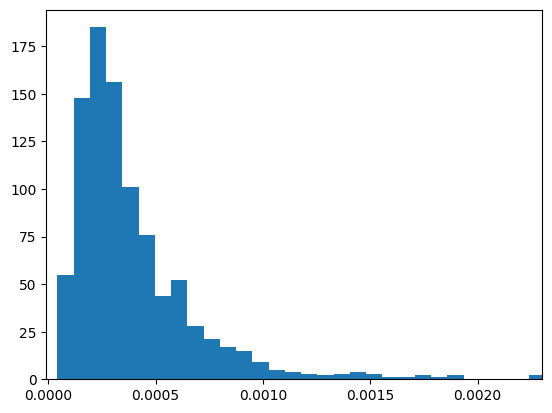

In [28]:
kmeans_df["Fleet CO2 Emissions Score\nIn the last 7 FY_avg_score_weighted"].value_counts()
plt.hist(kmeans_df["Fleet CO2 Emissions Score\nIn the last 7 FY_avg_score_weighted"], bins=100)
plt.xlim(-0.00001, 0.0023)
plt.show()

c:\Users\Coco\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\histograms.py:825: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
c:\Users\Coco\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\histograms.py:826: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


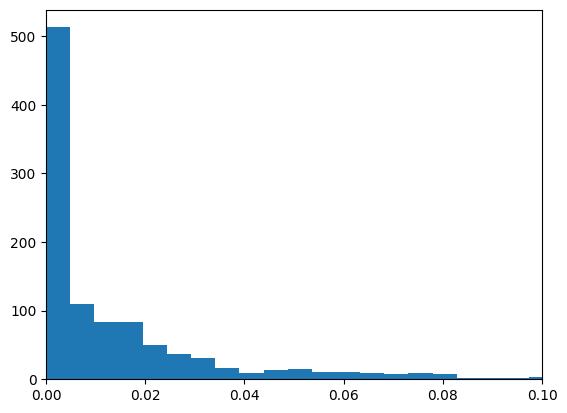

In [33]:
kmeans_df["Management Score Grade\nIn the last 7 FY_avg_score_weighted"].value_counts()
plt.hist(kmeans_df["Management Score Grade\nIn the last 7 FY_avg_score_weighted"], bins=100)
plt.xlim(0, 0.1)
plt.show()

In [44]:
dfs[48]

Management Score\nIn the last 7 FY                                   \
                                    FY0       FY-1       FY-2       FY-3   
0                             88.639876  98.893805  90.916272  85.813492   
1                             94.696970  90.101523  97.010870  87.187500   
2                             48.477157  52.445652  50.312500  42.156863   
3                             73.561151  61.469534  71.920290  86.548223   
4                             54.856115  54.659498  67.210145  55.583756   
...                                 ...        ...        ...        ...   
1090                          71.978022  73.076923  49.418605  16.265060   
1091                          45.833333  12.857143   4.285714   1.515152   
1095                          74.691358  50.000000  61.309524  54.081633   
1096                          41.187050  31.003584  13.586957  19.035533   
1098                          24.725275  11.538462   7.558140   6.626506   

                                      average_score    weight  \
           FY-4       FY-5       FY-6                           
0     94.874715  73.409669  76.893939      87.06311  0.002255   
1     53.267974  53.240741  50.000000     75.072225  0.002255   
2     67.129630  54.123711  55.154639     52.828593  0.002255   
3     66.379310  71.238938  55.851064      69.56693  0.002255   
4     31.896552  36.725664  54.787234     50.816995  0.002255   
...         ...        ...        ...           ...       ...   
1090   6.790123        NaN        NaN     43.505747  0.001691   
1091  11.666667        NaN        NaN     15.231602  0.001691   
1095   8.750000   8.333333  28.846154     40.858857  0.002255   
1096  17.528736   4.867257   2.659574      18.55267  0.002255   
1098   5.555556  11.206897  22.549020     12.822836  0.002255   

     avg_score_weighted  
                         
0              0.196309  
1              0.169272  
2              0.119117  
3              0.156859  
4              0.114582  
...                 ...  
1090           0.073572  
1091           0.025758  
1095           0.092128  
1096           0.041832  
1098           0.028913  

[632 rows x 10 columns]

In [47]:
temp_community_score = dfs[9]

In [48]:
temp_community_score

Community Score\nIn the last 7 FY                                   \
                                   FY0       FY-1       FY-2       FY-3   
0                            97.208738  98.271277  82.680723  95.979021   
1                            74.725275  51.069519  39.570552  75.337838   
2                            30.355277  46.875000  51.955990  30.574099   
3                            79.682702  71.839080  73.900463  79.156479   
4                            99.752475  99.742268  95.000000  89.779006   
...                                ...        ...        ...        ...   
1090                         24.938875  27.590674  30.865922  32.242991   
1091                         79.925651  46.963563  54.845815  55.927835   
1095                         47.583643  46.963563  54.845815  55.927835   
1096                         54.611650  77.526596  79.367470  80.944056   
1098                         68.625000  71.446701  70.266667  49.722992   

                                      average_score    weight  \
           FY-4       FY-5       FY-6                           
0     77.196653  72.303922  68.548387     84.598389  0.002255   
1     50.357143  53.461538  51.801802     56.617667  0.002255   
2     35.838150   6.216696   7.547170     29.908912  0.002255   
3     81.241656  84.609827  89.786856     80.031009  0.002255   
4     95.689655  68.154762  66.993464      87.87309  0.002255   
...         ...        ...        ...           ...       ...   
1090  27.083333        NaN        NaN     28.544359  0.001691   
1091  57.738095        NaN        NaN     59.080192  0.001691   
1095  36.011905  37.931034  26.209677     43.639068  0.002255   
1096  26.150628  13.480392  12.365591     49.206626  0.002255   
1098  86.307692  66.279070  72.336770     69.283556  0.002255   

     avg_score_weighted  
                         
0              0.190752  
1              0.127661  
2              0.067438  
3              0.180453  
4              0.198135  
...                 ...  
1090           0.048271  
1091            0.09991  
1095           0.098397  
1096           0.110951  
1098            0.15622  

[632 rows x 10 columns]

In [71]:
for i, score in temp_community_score.iterrows():
    above_100 = temp_community_score[temp_community_score['avg_score_weighted'] > 100]
    if above_100.empty:
        s=0
        #print("There are no values above 100 in avg_score_weighted.")
    else:
        print("There are values above 100 in avg_score_weighted.")


In [78]:
kmeans_df["Community Score\nIn the last 7 FY_avg_score_weighted"].value_counts()
selected_column = 'Community Score\nIn the last 7 FY_avg_score_weighted' 

rows_with_value_above_100 = kmeans_df[kmeans_df[selected_column] > 100]


In [101]:
rows_with_value_above_100["Community Score\nIn the last 7 FY_avg_score_weighted"]

21     191997.296703
45     110807.342752
54     266588.829932
113    146281.584511
212    934089.130298
           ...      
721      3089.028781
767     26139.194139
812      1100.714809
815      5760.217687
837      5747.507064
Name: Community Score\nIn the last 7 FY_avg_score_weighted, Length: 1078, dtype: object

In [113]:
num_community_scores = sum([1 for df_name in dfs if "Community Score\nIn the last 7 FY" or "Community Score Grade" in df_name])
print(f"There are {num_community_scores} dataframes with 'Community Score' in their name.")


There are 94 dataframes with 'Community Score' in their name.


In [115]:
for i, df in enumerate(dfs):
    print(f"Printing the {i}th dataframe")
    print(df)

Printing the 0th dataframe
    Agrochemical Products Score\nIn the last 7 FY                           \
                                              FY0 FY-1 FY-2 FY-3 FY-4 FY-5   
21                                            NaN  NaN  NaN  NaN  NaN  0.0   
45                                            0.0  NaN  NaN  NaN  NaN  NaN   
54                                            0.0  0.0  0.0  0.0  0.0  0.0   
113                                           NaN  NaN  NaN  NaN  0.0  0.0   
212                                           0.0  0.0  0.0  0.0  0.0  0.0   
229                                           NaN  NaN  NaN  0.0  0.0  0.0   
255                                           0.0  0.0  0.0  0.0  0.0  NaN   
350                                           0.0  0.0  0.0  0.0  NaN  NaN   
367                                           NaN  NaN  NaN  0.0  0.0  0.0   
428                                           NaN  NaN  0.0  0.0  0.0  NaN   
439                                  

In [107]:
num_community_score_cols = kmeans_df.columns.str.contains("Community Score").sum()
print("Number of columns with 'Community Score' in their name:", num_community_score_cols)
community_score_cols = kmeans_df.columns[kmeans_df.columns.str.contains('Community Score')]
print(community_score_cols)



Number of columns with 'Community Score' in their name: 2
Index(['Community Score\nIn the last 7 FY_avg_score_weighted', 'Community Score Grade\nIn the last 7 FY_avg_score_weighted'], dtype='object')


c:\Users\Coco\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\histograms.py:825: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
c:\Users\Coco\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\histograms.py:826: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


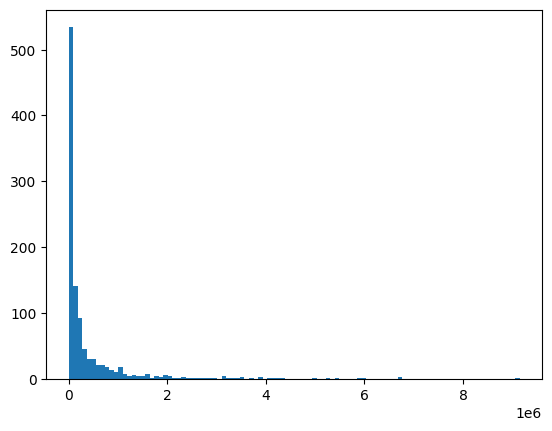

In [116]:
kmeans_df["Community Score\nIn the last 7 FY_avg_score_weighted"].value_counts()
plt.hist(kmeans_df["Community Score\nIn the last 7 FY_avg_score_weighted"], bins=100)
plt.show()

In [118]:
kmeans_df["Community Score Grade\nIn the last 7 FY_avg_score_weighted"]

21      0.198347
45      0.231405
54      0.231405
113     0.231405
212     0.231405
          ...   
767          NaN
812          NaN
815          NaN
837          NaN
1063         NaN
Name: Community Score Grade\nIn the last 7 FY_avg_score_weighted, Length: 1094, dtype: object

c:\Users\Coco\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\histograms.py:825: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
c:\Users\Coco\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\histograms.py:826: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


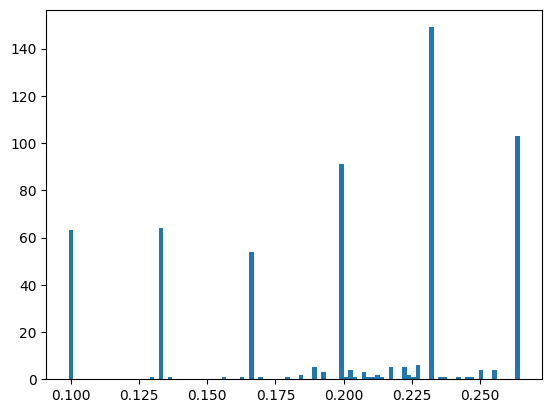

In [117]:
kmeans_df["Community Score Grade\nIn the last 7 FY_avg_score_weighted"].value_counts()
plt.hist(kmeans_df["Community Score Grade\nIn the last 7 FY_avg_score_weighted"], bins=100)
plt.show()

In [87]:
for i, df in enumerate(dfs):
    print(f"Printing the dataframe with index: {i}")
    print(df)

Printing the dataframe with index: 0
    Agrochemical Products Score\nIn the last 7 FY                           \
                                              FY0 FY-1 FY-2 FY-3 FY-4 FY-5   
21                                            NaN  NaN  NaN  NaN  NaN  0.0   
45                                            0.0  NaN  NaN  NaN  NaN  NaN   
54                                            0.0  0.0  0.0  0.0  0.0  0.0   
113                                           NaN  NaN  NaN  NaN  0.0  0.0   
212                                           0.0  0.0  0.0  0.0  0.0  0.0   
229                                           NaN  NaN  NaN  0.0  0.0  0.0   
255                                           0.0  0.0  0.0  0.0  0.0  NaN   
350                                           0.0  0.0  0.0  0.0  NaN  NaN   
367                                           NaN  NaN  NaN  0.0  0.0  0.0   
428                                           NaN  NaN  0.0  0.0  0.0  NaN   
439                        

In [100]:
new_df = community_score_df[community_score_df['avg_score_weighted'] > 100]
new_df

Empty DataFrame
Columns: [(Community Score
In the last 7 FY, FY0), (Community Score
In the last 7 FY, FY-1), (Community Score
In the last 7 FY, FY-2), (Community Score
In the last 7 FY, FY-3), (Community Score
In the last 7 FY, FY-4), (Community Score
In the last 7 FY, FY-5), (Community Score
In the last 7 FY, FY-6), (average_score, ), (weight, ), (avg_score_weighted, )]
Index: []

In [102]:
community_score_df

Community Score\nIn the last 7 FY                                   \
                                   FY0       FY-1       FY-2       FY-3   
0                            97.208738  98.271277  82.680723  95.979021   
1                            74.725275  51.069519  39.570552  75.337838   
2                            30.355277  46.875000  51.955990  30.574099   
3                            79.682702  71.839080  73.900463  79.156479   
4                            99.752475  99.742268  95.000000  89.779006   
...                                ...        ...        ...        ...   
1090                         24.938875  27.590674  30.865922  32.242991   
1091                         79.925651  46.963563  54.845815  55.927835   
1095                         47.583643  46.963563  54.845815  55.927835   
1096                         54.611650  77.526596  79.367470  80.944056   
1098                         68.625000  71.446701  70.266667  49.722992   

                                      average_score    weight  \
           FY-4       FY-5       FY-6                           
0     77.196653  72.303922  68.548387     84.598389  0.002255   
1     50.357143  53.461538  51.801802     56.617667  0.002255   
2     35.838150   6.216696   7.547170     29.908912  0.002255   
3     81.241656  84.609827  89.786856     80.031009  0.002255   
4     95.689655  68.154762  66.993464      87.87309  0.002255   
...         ...        ...        ...           ...       ...   
1090  27.083333        NaN        NaN     28.544359  0.001691   
1091  57.738095        NaN        NaN     59.080192  0.001691   
1095  36.011905  37.931034  26.209677     43.639068  0.002255   
1096  26.150628  13.480392  12.365591     49.206626  0.002255   
1098  86.307692  66.279070  72.336770     69.283556  0.002255   

     avg_score_weighted  
                         
0              0.190752  
1              0.127661  
2              0.067438  
3              0.180453  
4              0.198135  
...                 ...  
1090           0.048271  
1091            0.09991  
1095           0.098397  
1096           0.110951  
1098            0.15622  

[632 rows x 10 columns]

c:\Users\Coco\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\histograms.py:825: RuntimeWarning: invalid value encountered in greater_equal
  keep = (tmp_a >= first_edge)
c:\Users\Coco\AppData\Local\Programs\Python\Python312\Lib\site-packages\numpy\lib\histograms.py:826: RuntimeWarning: invalid value encountered in less_equal
  keep &= (tmp_a <= last_edge)


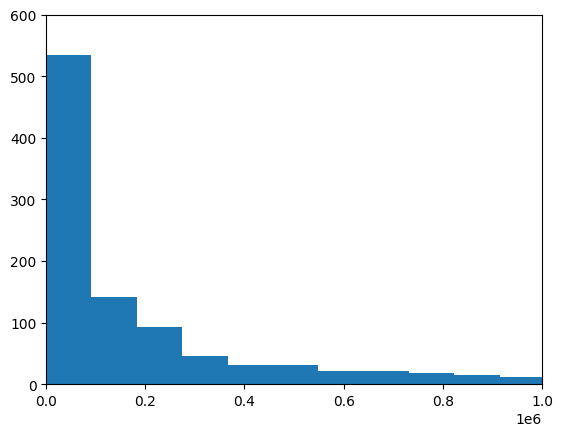

In [74]:
kmeans_df["Community Score\nIn the last 7 FY_avg_score_weighted"].value_counts()
plt.hist(kmeans_df["Community Score\nIn the last 7 FY_avg_score_weighted"], bins=100)
plt.xlim(-0.01, 1000000)
plt.ylim(0, 600)
plt.show()

In [76]:
temp_community_score.describe()

Community Score\nIn the last 7 FY                                      \
                                    FY0        FY-1        FY-2        FY-3   
count                        631.000000  627.000000  604.000000  511.000000   
mean                          55.321966   55.761940   55.360320   56.282098   
std                           30.516111   30.980184   31.108379   30.553464   
min                            0.328947    0.625000    0.888325    0.537634   
25%                           30.330245   29.289308   26.791915   28.671329   
50%                           58.474576   58.127208   58.412441   59.042553   
75%                           82.670807   84.369631   84.099265   84.788212   
max                           99.830508   99.873096   99.748744   99.780702   

                                           
             FY-4        FY-5        FY-6  
count  466.000000  369.000000  340.000000  
mean    55.445957   58.881053   57.404766  
std     30.301085   30.284688   31.784420  
min      0.819672    1.488095    1.209677  
25%     28.154838   32.080925   27.086032  
50%     58.305518   62.908012   62.178642  
75%     83.655172   87.016575   88.170385  
max     99.751244   99.723757   99.828179

In [73]:
for i,df in enumerate(dfs):
    print(f"Printing the dataframe at index {i}")
    print(df)

Printing the dataframe at index 0
    Agrochemical Products Score\nIn the last 7 FY                           \
                                              FY0 FY-1 FY-2 FY-3 FY-4 FY-5   
21                                            NaN  NaN  NaN  NaN  NaN  0.0   
45                                            0.0  NaN  NaN  NaN  NaN  NaN   
54                                            0.0  0.0  0.0  0.0  0.0  0.0   
113                                           NaN  NaN  NaN  NaN  0.0  0.0   
212                                           0.0  0.0  0.0  0.0  0.0  0.0   
229                                           NaN  NaN  NaN  0.0  0.0  0.0   
255                                           0.0  0.0  0.0  0.0  0.0  NaN   
350                                           0.0  0.0  0.0  0.0  NaN  NaN   
367                                           NaN  NaN  NaN  0.0  0.0  0.0   
428                                           NaN  NaN  0.0  0.0  0.0  NaN   
439                           

- remove rows that have only NaN values
- remove rows that have out that have more than 2stdv of Nan Values compared to actual values

In [ ]:
import pandas as pd
columns_with_missing_values = kmeans_df.columns[kmeans_df.isnull().any()].tolist()
columns_with_no_missing_values = kmeans_df.columns[kmeans_df.notnull().all()].tolist()
print(columns_with_missing_values)
# Create a dictionary with column names as keys and number of missing values as values
missing_values = {col: kmeans_df[col].isnull().sum() for col in kmeans_df.columns}

# Create a dataframe from the dictionary
missing_values_df = pd.DataFrame.from_dict(missing_values, orient='index', columns=['Missing Values'])

# Sort the dataframe by the number of missing values in descending order
missing_values_df = missing_values_df.sort_values(by='Missing Values', ascending=False)

# Reset the index of the dataframe
missing_values_df = missing_values_df.reset_index()

# Rename the columns of the dataframe
missing_values_df.columns = ['Column Name', 'Missing Values']

# Print the dataframe
print(missing_values_df)
import matplotlib.pyplot as plt

# Plot the distribution of missing values
plt.figure(figsize=(10, 6))
plt.hist(missing_values_df['Missing Values'], bins=10, edgecolor='black')
plt.xlabel('Missing Values')
plt.ylabel('Frequency')
plt.title('Distribution of Missing Values')
plt.show()

threshold = 980
filtered_variables = missing_values_df[missing_values_df['Missing Values'] <= threshold]['Column Name'].tolist()
